# Differential Analysis  
This notebook is designed for differential motif analysis using a mixed linear model. I used this to compare diseases states in the nPOD paper.

In [1]:
#library(data.table)
library(patchwork)
library(readr)
library(stringr)
library(dplyr)
set.seed(1234)

#### Send to channel code
library(parallel)
library(ggpubr)
library(qvalue)

library(pheatmap)
library(RColorBrewer)
library(beeswarm)
library(lme4)
library(lmerTest)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: ggplot2

Loading required package: Matrix


Attaching package: ‘lmerTest’


The following object is masked from ‘package:lme4’:

    lmer


The following object is masked from ‘package:stats’:

    step




## Read in data

In [2]:
in_dir <- '/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/'

#Load in devscores, info, motif
motifdata <- read.table(file=paste0(in_dir,'motifdata.txt'), sep="\t")
info <- read.table(file=paste0(in_dir,'info_table.txt'))
TFClass_Lookup <- read_csv("/nfs/lab/welison/References/220907_WE_Chromvar_to_Gene_By_Subfam_Complete(JAPRAR2022_TFClass).csv")
TFClass_Full <- read_csv("/nfs/lab/welison/References/220907_WE_Chromvar_to_Gene_Jaspar2022.csv")
variability <- read.table(file=paste0(in_dir,'variability.txt'), sep="\t")

head(motifdata)
head(info)
dim(TFClass_Lookup)
head(TFClass_Lookup)

head(variability)
dim(variability)

Rows: 10368 Columns: 4
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (4): full_jaspar_motif, jaspar_motif, lowest_level_family, gene

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1669 Columns: 20
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (20): full_jaspar_motif, jaspar_motif, jaspar_name_1, jaspar_name_2, TFC...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


,V1,V2,V3
,<chr>,<chr>,<chr>
1,MA0030.1_FOXF2,FOXF2,Fork head/winged helix factors
2,MA0031.1_FOXD1,FOXD1,Fork head/winged helix factors
3,MA0051.1_IRF2,IRF2,Tryptophan cluster factors
4,MA0059.1_MAX::MYC,MAX::MYC,Basic helix-loop-helix factors (bHLH)
5,MA0066.1_PPARG,PPARG,Nuclear receptors with C4 zinc fingers
6,MA0069.1_PAX6,PAX6,Paired box factors


,def,cells,groups,cluster,samples,FRIP,TSS.enrichment,nCount_ATAC,nFeature_ATAC
,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<int>,<int>
MM_339_AAACGAATCCCGAAGC-1,MM_339,MM_339_AAACGAATCCCGAAGC-1,earlyT1D,Acinar_1_2_6,6247,0.5421319,4.928013,748,715
MM_339_AAACGAATCTATGAGC-1,MM_339,MM_339_AAACGAATCTATGAGC-1,earlyT1D,Acinar_1_2_6,6247,0.7366399,5.622038,830,802
MM_339_AAACTCGGTGTGCTTA-1,MM_339,MM_339_AAACTCGGTGTGCTTA-1,earlyT1D,Acinar_1_2_6,6247,0.6134342,4.720066,505,489
MM_339_AAAGATGTCGGATGTT-1,MM_339,MM_339_AAAGATGTCGGATGTT-1,earlyT1D,Acinar_1_2_6,6247,0.6927803,4.036170,746,726
MM_339_AAAGGATAGGAGTCTG-1,MM_339,MM_339_AAAGGATAGGAGTCTG-1,earlyT1D,Acinar_1_2_6,6247,0.7235805,5.164169,621,602
MM_339_AAAGGATAGTCGAGCA-1,MM_339,MM_339_AAAGGATAGTCGAGCA-1,earlyT1D,Acinar_1_2_6,6247,0.5906291,4.659066,834,797


[1] 10368     4

full_jaspar_motif,jaspar_motif,lowest_level_family,gene
<chr>,<chr>,<chr>,<chr>
MA0030.1_FOXF2,FOXF2,FOXF,FOXF2
MA0030.1_FOXF2,FOXF2,FOXF,FOXF1
MA0031.1_FOXD1,FOXD1,FOXD,FOXD1
MA0031.1_FOXD1,FOXD1,FOXD,FOXD2
MA0031.1_FOXD1,FOXD1,FOXD,FOXD3
MA0031.1_FOXD1,FOXD1,FOXD,FOXD4L1


,name,variability,bootstrap_lower_bound,bootstrap_upper_bound,p_value,p_value_adj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MA0030.1_FOXF2,FOXF2,1.203838,1.198981,1.208643,0.000000e+00,0.000000e+00
MA0031.1_FOXD1,FOXD1,1.258115,1.252999,1.263342,0.000000e+00,0.000000e+00
MA0051.1_IRF2,IRF2,1.113662,1.108953,1.118249,0.000000e+00,0.000000e+00
MA0059.1_MAX::MYC,MAX::MYC,1.035252,1.031647,1.038709,1.326763e-95,1.932884e-95
MA0066.1_PPARG,PPARG,1.018128,1.014559,1.021752,6.234495e-27,7.676638e-27
MA0069.1_PAX6,PAX6,1.054041,1.049918,1.058356,2.990752e-220,5.306667e-220


[1] 692   6

In [3]:
# Load in sample level information 
wd_meta='/nfs/lab/rlmelton/npod/notebooks/sherlock/Downstream_analysis_nPOD_april2022/DESEQ_rna/'
meta.data =read.csv(paste0(wd_meta,'nPOD_clinical_July2022_nPOD_metadata_august2022_snATAC.csv'))
disease = meta.data[,c("SeqID_ATAC","Condition_subtype","Age","Sex","BMI","TSSe")]

# Merge sample and barcode level covariates
disease.meta <- left_join(select(info, SeqID_ATAC=def, groups, samples), disease)
disease.meta <- select(disease.meta, -SeqID_ATAC, -Condition_subtype, -TSSe)
disease.meta <- disease.meta[!duplicated(disease.meta),]

dim(disease.meta)
head(disease.meta)

Joining with `by = join_by(SeqID_ATAC)`


[1] 29  5

,groups,samples,Age,Sex,BMI
,<chr>,<int>,<dbl>,<chr>,<dbl>
1,earlyT1D,6247,24.00,Male,24.27
574,lateT1D,6418,24.86,Male,26.40
953,ND,6339,23.30,Male,25.00
1129,Aab,6197,22.00,Male,28.20
1522,earlyT1D,6380,11.60,Female,14.60
1697,ND,6375,28.70,Male,31.80


In [4]:
# This is the big one; the deviation scores. Runs slow
dev_file <- paste0(in_dir,'devscores.txt')

devscores <- vroom::vroom(file=dev_file, skip=1, col_names=FALSE)
devscores <- tibble::column_to_rownames(devscores, var="X1")
colnames(devscores) <- str_split(readLines(file(dev_file),n=1), " ")[[1]]

dim(devscores)
head(devscores)

Rows: 692 Columns: 174599
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: " "
chr      (1): X1
dbl (174598): X2, X3, X4, X5, X6, X7, X8, X9, X10, X11, X12, X13, X14, X15, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1]    692 174598

,MM_339_AAACGAATCCCGAAGC-1,MM_339_AAACGAATCTATGAGC-1,MM_339_AAACTCGGTGTGCTTA-1,MM_339_AAAGATGTCGGATGTT-1,MM_339_AAAGGATAGGAGTCTG-1,MM_339_AAAGGATAGTCGAGCA-1,MM_339_AAAGGGCCAGTCAGCC-1,MM_339_AAAGGGCTCGATATGC-1,MM_339_AAAGGGCTCGGTTAGT-1,MM_339_AAATGAGGTGCCAAGA-1,⋯,MM_391_GTGCCAGCAGGGTAAC-1,MM_460_AAATGCCGTGCATTGT-1,MM_460_GCACCTTCATGCGCTG-1,MM_460_GTAATCGCAAAGAAGG-1,MM_460_TAGTCCCAGAAAGCAG-1,MM_460_TTCATTGTCGCAAACT-1,MM_536_GGAGGATCATCCCTCA-1,MM_544_CTAGCGGGTTTAGACC-1,MM_546_GCACGGTCAGTCAGCC-1,MM_546_TTGCAGAGTTCTGAGT-1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MA0030.1_FOXF2,0.54520151,0.40990183,3.35607428,2.000801239,0.9658235,-0.459021816,0.44334913,-0.25558497,-1.6471011,0.8835954,⋯,-1.3485672,-1.24054617,0.6432168,0.53422671,-0.8512291,0.34641291,-1.3156336,-0.1606987,-0.4841276,-0.1220044
MA0031.1_FOXD1,-0.64639620,0.56733851,2.16471443,0.222432873,0.1040411,-1.840425687,1.07262678,-0.05391174,1.3205662,0.8736271,⋯,-2.0031346,-1.47942813,-0.2572786,-0.84672181,-1.4112522,-1.44849245,-1.0407649,-0.3555410,-2.0004751,-1.9848008
MA0051.1_IRF2,-0.04734576,0.21278816,-1.17043162,0.006864465,-0.6147434,0.779877039,-0.95418391,0.84427104,-0.1533793,-0.6127317,⋯,0.3081769,0.92292903,1.0573372,0.55484583,-0.8093365,1.63052376,0.6905937,-1.1745899,3.0360215,0.9012208
MA0059.1_MAX::MYC,-0.01129497,0.06407827,-0.60875582,-0.568995229,1.0334839,0.008193637,-1.30026440,-0.93085128,-2.0120367,-0.2730295,⋯,-1.1595347,0.42933240,2.3681214,-1.55277513,-1.3609323,-1.10154128,-1.9283999,-0.4375171,-0.9435472,-1.2343960
MA0066.1_PPARG,0.51365043,-0.50851101,-0.55188880,-0.488296947,-0.6396850,0.131552195,-0.30285472,1.31740292,1.8427194,0.4069058,⋯,1.3590695,0.03172931,0.1511277,0.35230581,-1.8023297,-0.83032002,0.4737512,-0.1385413,-0.9820997,-0.3458552
MA0069.1_PAX6,-2.20269142,-0.84260738,-0.01861448,0.711684614,-1.0814076,0.492742898,0.09633553,-0.41465127,-1.0573779,0.4792118,⋯,-0.5531416,1.12677198,-0.6887637,0.07516654,-1.1501492,0.08811665,-1.6427782,-0.6124164,-0.0492491,-2.0683459


## Generate Cell Type Specific Inputs

In [5]:
cell_types <- unique(info$cluster)
names(cell_types) <- cell_types
cell_types

Acinar_1_2_6             Acinar_5             Acinar_3 
      "Acinar_1_2_6"           "Acinar_5"           "Acinar_3" 
            Acinar_4               Ductal   Activated_Stellate 
          "Acinar_4"             "Ductal" "Activated_Stellate" 
         Endothelial              Schwann                Alpha 
       "Endothelial"            "Schwann"              "Alpha" 
               Delta                 Beta           Macrophage 
             "Delta"               "Beta"         "Macrophage" 
              Tcells                 Mast   Quiescent_Stellate 
            "Tcells"               "Mast" "Quiescent_Stellate" 
           LymphEndo               Bcells         MUC5b_Ductal 
         "LymphEndo"             "Bcells"       "MUC5b_Ductal"

In [6]:
ct_info <- lapply(cell_types, FUN=function(x) {filter(info, cluster==x)})
summary(ct_info)

                   Length Class      Mode
Acinar_1_2_6       9      data.frame list
Acinar_5           9      data.frame list
Acinar_3           9      data.frame list
Acinar_4           9      data.frame list
Ductal             9      data.frame list
Activated_Stellate 9      data.frame list
Endothelial        9      data.frame list
Schwann            9      data.frame list
Alpha              9      data.frame list
Delta              9      data.frame list
Beta               9      data.frame list
Macrophage         9      data.frame list
Tcells             9      data.frame list
Mast               9      data.frame list
Quiescent_Stellate 9      data.frame list
LymphEndo          9      data.frame list
Bcells             9      data.frame list
MUC5b_Ductal       9      data.frame list

In [7]:
head(ct_info[['Beta']])

,def,cells,groups,cluster,samples,FRIP,TSS.enrichment,nCount_ATAC,nFeature_ATAC
,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<int>,<int>
MM_385_GTAGACTCACCGATCG-1,MM_385,MM_385_GTAGACTCACCGATCG-1,Aab,Beta,6310,0.6697896,3.737384,3128,2687
MM_341_CGCACAGGTCCGAGCT-1,MM_341,MM_341_CGCACAGGTCCGAGCT-1,ND,Beta,6339,0.3371609,2.967033,2018,1108
MM_342_ATTACCTGTCGTAATC-1,MM_342,MM_342_ATTACCTGTCGTAATC-1,Aab,Beta,6197,0.4275936,3.344519,13243,6352
MM_342_CATTCATTCGATGAAA-1,MM_342,MM_342_CATTCATTCGATGAAA-1,Aab,Beta,6197,0.4517270,2.950673,7605,3715
MM_342_GTGACATCACCGTTGG-1,MM_342,MM_342_GTGACATCACCGTTGG-1,Aab,Beta,6197,0.4117878,2.837341,11008,5314
MM_342_GTGCACGCATTTCTTG-1,MM_342,MM_342_GTGCACGCATTTCTTG-1,Aab,Beta,6197,0.4456573,3.630332,10042,4772


In [8]:
ct_devscores <- lapply(cell_types, FUN=function(x) {devscores[rownames(ct_info[[x]])]})
summary(ct_devscores)

                   Length Class      Mode
Acinar_1_2_6       111011 data.frame list
Acinar_5             1377 data.frame list
Acinar_3            20368 data.frame list
Acinar_4              436 data.frame list
Ductal              21794 data.frame list
Activated_Stellate   5398 data.frame list
Endothelial          1976 data.frame list
Schwann                16 data.frame list
Alpha                2328 data.frame list
Delta                 209 data.frame list
Beta                 1915 data.frame list
Macrophage           4748 data.frame list
Tcells               2069 data.frame list
Mast                   12 data.frame list
Quiescent_Stellate    873 data.frame list
LymphEndo              58 data.frame list
Bcells                  8 data.frame list
MUC5b_Ductal            2 data.frame list

In [9]:
#ct_meta <- lapply(cell_types, FUN=function(x) {tibble::rownames_to_column(select(filter(meta, FinalSubtypes==x), TSS.enrichment, frac_reads_in_peaks, nCount_ATAC, nFeature_ATAC), var='bc')})
#summary(ct_meta)

# Significance Testing  

Current model: Mixed effect linear model. Standard effects in a linear model are called "fixed" effects. A mixed effects model includes "random" effects, which can be way oversimplified as batch variables. In this case the recommended way based on literature to account for the pseudoreplication of barcodes coming from the same individual is to use a random effect allowing for different y-intercepts between individuals.

In [10]:
# Combine different meta data and the deviation scores. This is slow because the deviation scores need to be transposed
barcode_motif_matrix_bc_joined <- lapply(cell_types, 
                FUN=function(x) {left_join(left_join(tibble::rownames_to_column(as.data.frame(t(ct_devscores[[x]])), var="barcode"), 
                    select(ct_info[[x]], samples, cells, FRIP, TSS.enrichment, nCount_ATAC ,nFeature_ATAC), join_by(barcode==cells)),disease.meta)})

summary(barcode_motif_matrix_bc_joined)
dim(barcode_motif_matrix_bc_joined[['Beta']])
head(barcode_motif_matrix_bc_joined[['Beta']])

Joining with `by = join_by(samples)`
Joining with `by = join_by(samples)`
Joining with `by = join_by(samples)`
Joining with `by = join_by(samples)`
Joining with `by = join_by(samples)`
Joining with `by = join_by(samples)`
Joining with `by = join_by(samples)`
Joining with `by = join_by(samples)`
Joining with `by = join_by(samples)`
Joining with `by = join_by(samples)`
Joining with `by = join_by(samples)`
Joining with `by = join_by(samples)`
Joining with `by = join_by(samples)`
Joining with `by = join_by(samples)`
Joining with `by = join_by(samples)`
Joining with `by = join_by(samples)`
Joining with `by = join_by(samples)`
Joining with `by = join_by(samples)`


                   Length Class      Mode
Acinar_1_2_6       702    data.frame list
Acinar_5           702    data.frame list
Acinar_3           702    data.frame list
Acinar_4           702    data.frame list
Ductal             702    data.frame list
Activated_Stellate 702    data.frame list
Endothelial        702    data.frame list
Schwann            702    data.frame list
Alpha              702    data.frame list
Delta              702    data.frame list
Beta               702    data.frame list
Macrophage         702    data.frame list
Tcells             702    data.frame list
Mast               702    data.frame list
Quiescent_Stellate 702    data.frame list
LymphEndo          702    data.frame list
Bcells             702    data.frame list
MUC5b_Ductal       702    data.frame list

[1] 1915  702

,barcode,MA0030.1_FOXF2,MA0031.1_FOXD1,MA0051.1_IRF2,MA0059.1_MAX::MYC,MA0066.1_PPARG,MA0069.1_PAX6,MA0070.1_PBX1,MA0071.1_RORA,MA0072.1_RORA,⋯,MA0597.2_THAP1,samples,FRIP,TSS.enrichment,nCount_ATAC,nFeature_ATAC,groups,Age,Sex,BMI
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<int>,<dbl>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>,<dbl>
1,MM_385_GTAGACTCACCGATCG-1,0.7606630,0.2680993,-0.8818435,1.176793,-1.15104945,-0.4719544,2.65318503,-0.9887489,-0.2210390,⋯,-0.06602532,6310,0.6697896,3.737384,3128,2687,Aab,28.0,Female,22.4
2,MM_341_CGCACAGGTCCGAGCT-1,-0.2907406,2.2819599,0.9701550,1.382532,-0.30196136,0.2904214,2.11002768,1.2943334,3.1710316,⋯,-2.04772981,6339,0.3371609,2.967033,2018,1108,ND,23.3,Male,25.0
3,MM_342_ATTACCTGTCGTAATC-1,4.4616127,3.3484831,-2.3067211,-1.062446,-0.79450012,3.7180205,0.23995835,-0.9562603,1.0954505,⋯,-0.17726216,6197,0.4275936,3.344519,13243,6352,Aab,22.0,Male,28.2
4,MM_342_CATTCATTCGATGAAA-1,3.8597990,3.9731843,-1.7979045,2.913300,-2.39154606,3.3147598,-1.43086593,-0.4325314,0.2164518,⋯,-1.02853881,6197,0.4517270,2.950673,7605,3715,Aab,22.0,Male,28.2
5,MM_342_GTGACATCACCGTTGG-1,4.1064427,4.8111082,-0.7701096,1.633552,-0.05196291,2.3300916,-0.27031029,-2.1845530,0.2317018,⋯,0.23173319,6197,0.4117878,2.837341,11008,5314,Aab,22.0,Male,28.2
6,MM_342_GTGCACGCATTTCTTG-1,2.5267740,3.4241907,-1.8741887,0.158396,-0.18597196,3.6307648,-0.01892572,1.1252034,1.8683790,⋯,-1.34202602,6197,0.4456573,3.630332,10042,4772,Aab,22.0,Male,28.2


In [11]:
# This runs our linear model! 
# The way I ran it is a little over complicated because I am trying to allow for 
# dropout of conditions and samples based on # of barcode filters and # of samples filters

#Lists to save outputs
cond_passing <- list()
test_data <- list()
results_df <- list()
new_df_list <- list()

for (cell in cell_types) {
#for (cell in c('Beta')) {
    print(cell)
    new_df <- barcode_motif_matrix_bc_joined[[cell]]
    new_df$samples <- as.character(new_df$samples) # Sample names were numbers; the formula tried to treat this as a continuous variable
    new_df$Sex <- as.numeric(as.factor(new_df$Sex)) # Binarize, skip if not in model

    # Remove low count samples
    new_df <- filter(new_df, samples %in% names(which(table(barcode_motif_matrix_bc_joined[[cell]]$samples)  > 10)))

    # Count samples per condition and pick those to test
    samp_table <- group_by(new_df, samples, groups) %>% summarise(n()) %>% select(samples, groups) %>% table() %>% colSums()
    cond_to_test <- names(samp_table)[samp_table > 2]
    cond_passing[[cell]] <- cond_to_test
    cond_to_test <- cond_to_test[cond_to_test != 'ND'] # Replace ND with control label

    if (is.null(cond_to_test)) {
        print("Not enough things to test")
        next
    } 
    if (sum(samp_table > 2) < 2) {
        print("Not enough things to test")
        next
    }
    # These are the covariates I left in the matrix, most I am not using but tried out
    covariates <- c('groups', 'samples', 'Age', 'Sex', 'BMI', 'TSS.enrichment', 
                'FRIP', 'nCount_ATAC', 'nFeature_ATAC')

    # Encoded Variables (dummy variables) need to be created that represent the comparison of each condition to control
    # They are weighted so each column of dummy variable sums to 0. Why? Because people who know more said so...
    if ("Aab" %in% cond_to_test) {
        new_df$Aab_weighted_barcode <- as.integer(new_df$groups=='Aab')
        new_df$Aab_weighted_barcode[new_df$groups=='ND'] <- -(sum(new_df$groups=='Aab')/sum(new_df$groups=='ND'))
    }
    if ("earlyT1D" %in% cond_to_test) {
        new_df$earlyT1D_weighted_barcode <- as.integer(new_df$groups=='earlyT1D')
        new_df$earlyT1D_weighted_barcode[new_df$groups=='ND'] <- -(sum(new_df$groups=='earlyT1D')/sum(new_df$groups=='ND'))
    }
    if ("lateT1D" %in% cond_to_test) {
        new_df$lateT1D_weighted_barcode <- as.integer(new_df$groups=='lateT1D')
        new_df$lateT1D_weighted_barcode[new_df$groups=='ND'] <- -(sum(new_df$groups=='lateT1D')/sum(new_df$groups=='ND'))
    }

    # Restructure data to make a little simpler
    # new_df$groups <- factor(new_df$groups, levels=c('ND','Aab','earlyT1D', 'lateT1D')) # I don't think this is necessary but helped downstream
    
    # Moved all motifs to the end so I could iterate through them
    # This got a little convoluted to handle different conditions per cell type
    # Instead could replace the select any section with discrete conditions
    new_df <- arrange(new_df, groups) %>%
            select(any_of(paste0(cond_to_test, '_weighted_barcode')), any_of(covariates), 'barcode', everything())

    # Create a data frame to hold output. 
    # This got a little convoluted to handle different conditions per cell type
    # Instead could replace nrow with the number of non-motif columns and ncol with number of output columns (1 for motif label + 3 for each condition)
    FRIP.Count = data.frame(matrix(nrow=nrow(ct_devscores[[cell]]), 
                               ncol = (1 + (3 * length(cond_to_test)))))
    rownames(FRIP.Count)= colnames(as.data.frame(t(ct_devscores[[cell]])))
    colnames(FRIP.Count) <- c('Motif', paste0('lmer.', rep(cond_to_test, each=3), c('.est','.t','.p')))

    # Save data to check after if needed and write some outputs for sanity check
    test_data[[cell]] <- new_df
    print(paste0("Rows of test data (barcodes) ", nrow(new_df)))
    print(paste0("Columns of test data (barcodes) ", ncol(new_df)))
    print(paste0("Conditions tested: ", paste(cond_to_test, collapse=' ')))

    # This test runs per motif, so we will iterate throught the number of motifs. the first number after in could be the column of the first motif
    for(i in ((length(c(cond_to_test,covariates, 'barcode'))) + 1):ncol(new_df)){
    #for(i in 17:23){
        column <- names(new_df[i])
        # Construct the test formula.
        # This got a little convoluted to handle different conditions per cell type
        # Instead could replace paste section with "cond_to_test" with the names of the columns of the condition encoding variables
        form <- as.formula(paste0("new_df[,i] ~ ", paste(paste0(cond_to_test,"_weighted_barcode"), collapse=' + '), " + scale(FRIP) + scale(nCount_ATAC) + (1|samples)"))
        # Run the test
        mod1=lmerTest::lmer(form, data = new_df)

        # Save the outputs
        FRIP.Count[column,'Motif'] <- column
    
        for (cond in cond_to_test) {
            FRIP.Count[column, paste0('lmer.',cond,'.est')] <- summary(mod1)[['coefficients']][paste0(cond,"_weighted_barcode"),'Estimate']
            FRIP.Count[column, paste0('lmer.',cond,'.t')] <- summary(mod1)[['coefficients']][paste0(cond,"_weighted_barcode"),'t value']
            FRIP.Count[column, paste0('lmer.',cond,'.p')] <- summary(mod1)[['coefficients']][paste0(cond,"_weighted_barcode"),'Pr(>|t|)']
        }
    }

    # Calculate FDR. I prefer q-values for FDR but you can sub in anything
    for (cond in cond_to_test) {
        FRIP.Count[paste0('lmer.',cond,'.q')] <- qvalue(FRIP.Count[[paste0('lmer.',cond,'.p')]])$qvalues
    }
    # Save to output list and tidy
    results_df[[cell]] <- FRIP.Count
    gc()
    
    new_df_list[[cell]] <- new_df
}

summary(results_df, lmer.earlyT1D.p)
head(results_df[['Beta']])

[1] "Acinar_1_2_6"


`summarise()` has grouped output by 'samples'. You can override using the `.groups` argument.


[1] "Rows of test data (barcodes) 111011"
[1] "Columns of test data (barcodes) 705"
[1] "Conditions tested: Aab earlyT1D lateT1D"


boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')



[1] "Acinar_5"


...

[1] "Not enough things to test"
[1] "MUC5b_Ductal"


`summarise()` has grouped output by 'samples'. You can override using the `.groups` argument.


[1] "Not enough things to test"


                   Length Class      Mode
Acinar_1_2_6       13     data.frame list
Acinar_5           13     data.frame list
Acinar_3           13     data.frame list
Acinar_4            9     data.frame list
Ductal             13     data.frame list
Activated_Stellate 13     data.frame list
Endothelial        13     data.frame list
Alpha              13     data.frame list
Beta                9     data.frame list
Macrophage         13     data.frame list
Tcells             13     data.frame list
Quiescent_Stellate 13     data.frame list

,Motif,lmer.Aab.est,lmer.Aab.t,lmer.Aab.p,lmer.earlyT1D.est,lmer.earlyT1D.t,lmer.earlyT1D.p,lmer.Aab.q,lmer.earlyT1D.q
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MA0030.1_FOXF2,MA0030.1_FOXF2,0.02773718,0.2850702,0.7792972,-0.23895569,-1.532156,0.143646012,0.9912625,0.5757256
MA0031.1_FOXD1,MA0031.1_FOXD1,0.04143519,0.4862345,0.6334027,-0.44272495,-3.213367,0.004818377,0.9912625,0.2969243
MA0051.1_IRF2,MA0051.1_IRF2,-0.01820752,-0.2108901,0.8358119,0.17384808,1.250906,0.228283785,0.9912625,0.5757256
MA0059.1_MAX::MYC,MA0059.1_MAX::MYC,0.02773520,0.3285589,0.7471467,0.16370396,1.204413,0.245698912,0.9912625,0.5757256
MA0066.1_PPARG,MA0066.1_PPARG,-0.03631797,-0.7158810,0.4846176,0.09219805,1.096852,0.286316234,0.9912625,0.6019082
MA0069.1_PAX6,MA0069.1_PAX6,-0.01876289,-0.2892011,0.7765072,-0.15059888,-1.409099,0.176342435,0.9912625,0.5757256


In [12]:
results_df_renamed <- list()

for (cell in names(results_df)) {
    new_names <- c("Motif")
    q_names <- character(0)
    if (any(str_detect(colnames(results_df[[cell]]), "Aab"))) {
        new_names <- c(new_names, "Aab.Effect","Aab.Test.Statistic","Aab.p.value")
        q_names <- c(q_names, 'Aab.q.value')
    }
    if (any(str_detect(colnames(results_df[[cell]]), "earlyT1D"))) {
        new_names <- c(new_names, "earlyT1D.Effect","earlyT1D.Test.Statistic","earlyT1D.p.value")
        q_names <- c(q_names, 'earlyT1D.q.value')
    }
    if (any(str_detect(colnames(results_df[[cell]]), "lateT1D"))) {
        new_names <- c(new_names, "lateT1D.Effect","lateT1D.Test.Statistic","lateT1D.p.value")
        q_names <- c(q_names, 'lateT1D.q.value')
    }
    
    new_names <- c(new_names, q_names)

    results_df_renamed[[cell]] <- results_df[[cell]]

    colnames(results_df_renamed[[cell]]) <- new_names
}

summary(results_df_renamed)

                   Length Class      Mode
Acinar_1_2_6       13     data.frame list
Acinar_5           13     data.frame list
Acinar_3           13     data.frame list
Acinar_4            9     data.frame list
Ductal             13     data.frame list
Activated_Stellate 13     data.frame list
Endothelial        13     data.frame list
Alpha              13     data.frame list
Beta                9     data.frame list
Macrophage         13     data.frame list
Tcells             13     data.frame list
Quiescent_Stellate 13     data.frame list

In [13]:
for (cell in names(results_df)) {
    print(head(arrange(results_df_renamed[[cell]], earlyT1D.q.value)))
}

                              Motif   Aab.Effect Aab.Test.Statistic Aab.p.value
MA0030.1_FOXF2       MA0030.1_FOXF2 -0.021520476         -1.0852657   0.2880639
MA0031.1_FOXD1       MA0031.1_FOXD1 -0.018046695         -0.7715905   0.4474720
MA0051.1_IRF2         MA0051.1_IRF2  0.002730683          0.1077097   0.9150804
MA0059.1_MAX::MYC MA0059.1_MAX::MYC  0.014192792          0.7514700   0.4590778
MA0066.1_PPARG       MA0066.1_PPARG -0.005846822         -0.6095713   0.5472526
MA0069.1_PAX6         MA0069.1_PAX6 -0.010509170         -1.4221193   0.1739784
                  earlyT1D.Effect earlyT1D.Test.Statistic earlyT1D.p.value
MA0030.1_FOXF2        0.009110942              0.41248557        0.6835817
MA0031.1_FOXD1        0.002593979              0.09932357        0.9216877
MA0051.1_IRF2        -0.004973319             -0.17523064        0.8623499
MA0059.1_MAX::MYC     0.010305727              0.49020786        0.6282040
MA0066.1_PPARG        0.004452799              0.41989973        

In [14]:
for (cell in names(summary(results_df)[,1])[summary(results_df)[,1] == '13']) {
    print(head(arrange(results_df_renamed[[cell]], lateT1D.q.value)))
}

                        Motif   Aab.Effect Aab.Test.Statistic Aab.p.value
MA0030.1_FOXF2 MA0030.1_FOXF2 -0.021520476         -1.0852657   0.2880639
MA0031.1_FOXD1 MA0031.1_FOXD1 -0.018046695         -0.7715905   0.4474720
MA0066.1_PPARG MA0066.1_PPARG -0.005846822         -0.6095713   0.5472526
MA0070.1_PBX1   MA0070.1_PBX1 -0.012115142         -1.3003020   0.2059629
MA0071.1_RORA   MA0071.1_RORA  0.005379149          0.3511475   0.7284921
MA0072.1_RORA   MA0072.1_RORA -0.003139653         -0.2655499   0.7926958
               earlyT1D.Effect earlyT1D.Test.Statistic earlyT1D.p.value
MA0030.1_FOXF2     0.009110942              0.41248557        0.6835817
MA0031.1_FOXD1     0.002593979              0.09932357        0.9216877
MA0066.1_PPARG     0.004452799              0.41989973        0.6779077
MA0070.1_PBX1      0.003358940              0.32610964        0.7472072
MA0071.1_RORA      0.003359445              0.19764684        0.8450002
MA0072.1_RORA      0.015102462              1.1540

In [15]:
for (cell in names(results_df)) {
    print(head(arrange(results_df_renamed[[cell]], Aab.q.value)))
}

                        Motif  Aab.Effect Aab.Test.Statistic Aab.p.value
MA0647.1_GRHL1 MA0647.1_GRHL1  0.03102115           2.537777 0.017622875
MA0732.1_EGR3   MA0732.1_EGR3 -0.03509429          -2.913543 0.007388214
MA0733.1_EGR4   MA0733.1_EGR4 -0.03256808          -3.116748 0.004775022
MA0758.1_E2F7   MA0758.1_E2F7 -0.02408092          -3.231863 0.003569595
MA0600.2_RFX2   MA0600.2_RFX2 -0.05296219          -2.545639 0.017092462
MA0855.1_RXRB   MA0855.1_RXRB  0.02817837           2.349889 0.027351268
               earlyT1D.Effect earlyT1D.Test.Statistic earlyT1D.p.value
MA0647.1_GRHL1    1.674139e-02            1.237484e+00        0.2273428
MA0732.1_EGR3     6.501909e-03            4.864559e-01        0.6309537
MA0733.1_EGR4     1.371945e-02            1.186297e+00        0.2475485
MA0758.1_E2F7     6.071427e-04            7.370873e-02        0.9418534
MA0600.2_RFX2    -3.473283e-02           -1.496750e+00        0.1467501
MA0855.1_RXRB    -8.639907e-07           -6.509349e-05   

In [16]:
for (cell in names(results_df_renamed)) {
    write.table(arrange(results_df_renamed[[cell]], earlyT1D.q.value), 
                paste0('/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240209_WE_',cell,'_Disease_mixed_model_outs.tsv'),
                sep='\t',row.names=F, col.names=T, quote=F)
}

In [17]:
for (cell in names(new_df_list)) {
    write.table(new_df_list[[cell]], 
                paste0('/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240209_WE_',cell,'_Disease_mixed_model_data.tsv'),
                sep='\t',row.names=F, col.names=T, quote=F)
}

# Graphing - TO DO  

##### Ideas:
-Volcano plot (1 cell type, ND vs condition)  
-Heatmap (1 cell type, all conditions, sig marked by *)  
-Sample level boxplots (1 box per condition)  
-Barcode level boxplots (1 box per sample, grouped by condition)  

### Volcano

In [18]:
# Average motif by sample

sample_data <- list()

for (cell in names(results_df_renamed)) {
    sample_data[[cell]] <- select(new_df_list[[cell]], -Aab_weighted_barcode, -earlyT1D_weighted_barcode, -Age, -Sex, -BMI,
       -TSS.enrichment, -FRIP, -nCount_ATAC, -nFeature_ATAC, -barcode) %>%
            group_by(groups, samples) %>%
            summarise_all(mean, na.rm=T)
}

summary(sample_data)
dim(sample_data[['Beta']])
head(sample_data[['Beta']])

                   Length Class      Mode
Acinar_1_2_6       695    grouped_df list
Acinar_5           695    grouped_df list
Acinar_3           695    grouped_df list
Acinar_4           694    grouped_df list
Ductal             695    grouped_df list
Activated_Stellate 695    grouped_df list
Endothelial        695    grouped_df list
Alpha              695    grouped_df list
Beta               694    grouped_df list
Macrophage         695    grouped_df list
Tcells             695    grouped_df list
Quiescent_Stellate 695    grouped_df list

[1]  19 694

groups,samples,MA0030.1_FOXF2,MA0031.1_FOXD1,MA0051.1_IRF2,MA0059.1_MAX::MYC,MA0066.1_PPARG,MA0069.1_PAX6,MA0070.1_PBX1,MA0071.1_RORA,⋯,MA1511.2_KLF10,MA1525.2_NFATC4,MA1532.2_NR1D2,MA1547.2_PITX2,MA1563.2_SOX18,MA1566.2_TBX3,MA1601.2_ZNF75D,MA1630.2_ZNF281,MA1633.2_BACH1,MA0597.2_THAP1
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Aab,6197,2.857429,2.860531,-0.9811797,0.39007216,-0.26512313,1.757859,0.7917269,-0.2703282090,⋯,-0.6696456,1.027379,-0.41786663,0.5450014,-0.4744134,-0.12747310,-0.7268262,-0.22993226,-3.47392000,-0.31415599
Aab,6267,1.860634,1.903372,-0.8177361,0.86725028,0.04063517,1.459343,0.3639584,0.0006624538,⋯,-0.4314229,1.513212,-0.09334161,0.3764946,-0.6612990,0.40020625,-0.5936006,-0.05057467,0.09774571,0.12242960
Aab,6424,2.484501,2.390254,-0.4141324,0.04704163,-0.38651029,2.133007,0.4808262,-0.1870447233,⋯,-0.8010450,1.349239,-0.35767515,0.6037999,-0.3738545,0.05808414,-0.5813791,-0.59525931,-1.21851120,-0.21931572
Aab,6429,2.237114,2.278920,-0.8383157,0.29009326,-0.12217415,1.417371,1.0484290,-0.1363430361,⋯,-0.8722497,1.424488,-0.37682011,0.3981130,-0.5108478,0.01219261,-0.5460460,-0.69083363,-2.81044507,-0.09660275
Aab,6450,2.115093,1.987055,-0.8780517,1.17216206,-0.03567387,1.307238,0.4696527,-0.0769514091,⋯,-0.5587101,2.075482,-0.05366765,0.3765272,-0.2963673,-0.13200643,-0.5715724,-0.21078352,0.08741107,0.14406987
Aab,6505,1.902494,2.186824,-0.5803057,0.07523361,-0.25680290,1.276026,0.8166820,-0.2661216285,⋯,-0.6883667,1.227863,-0.19106434,0.1579877,-0.0366350,0.12976416,-0.3937469,-0.51164437,-1.23870739,-0.12626308


In [19]:
# Average motif by disease state

group_data <- list()

for (cell in names(sample_data)) {
    group_data[[cell]] <- select(sample_data[[cell]], -samples) %>%
            group_by(groups) %>%
            summarise_all(mean, na.rm=T)
}

summary(group_data)
dim(group_data[['Beta']])
head(group_data[['Beta']])

                   Length Class  Mode
Acinar_1_2_6       694    tbl_df list
Acinar_5           694    tbl_df list
Acinar_3           694    tbl_df list
Acinar_4           693    tbl_df list
Ductal             694    tbl_df list
Activated_Stellate 694    tbl_df list
Endothelial        694    tbl_df list
Alpha              694    tbl_df list
Beta               693    tbl_df list
Macrophage         694    tbl_df list
Tcells             694    tbl_df list
Quiescent_Stellate 694    tbl_df list

[1]   3 693

groups,MA0030.1_FOXF2,MA0031.1_FOXD1,MA0051.1_IRF2,MA0059.1_MAX::MYC,MA0066.1_PPARG,MA0069.1_PAX6,MA0070.1_PBX1,MA0071.1_RORA,MA0072.1_RORA,⋯,MA1511.2_KLF10,MA1525.2_NFATC4,MA1532.2_NR1D2,MA1547.2_PITX2,MA1563.2_SOX18,MA1566.2_TBX3,MA1601.2_ZNF75D,MA1630.2_ZNF281,MA1633.2_BACH1,MA0597.2_THAP1
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Aab,2.242011,2.264140,-0.6843334,0.4408855,-0.16395025,1.573346,0.6442481,-0.1753196,0.2204071,⋯,-0.6802063,1.452999,-0.2706122,0.4095547,-0.3681477,0.05174608,-0.5687519,-0.3899620,-1.650520,-0.10498904
ND,2.278086,2.337145,-0.6664534,0.3218717,-0.17560012,1.677918,0.7707289,-0.2954247,0.1767948,⋯,-0.6282202,1.656933,-0.2873285,0.3617666,-0.3273597,-0.04318980,-0.5243711,-0.3513095,-2.292179,-0.18996940
earlyT1D,1.945234,1.728518,-0.4945870,0.5210940,-0.07829518,1.470386,0.5378442,-0.2214101,0.2312356,⋯,-0.6764868,1.510252,-0.3293363,0.1998923,-0.3529177,-0.14292372,-0.6717869,-0.4225353,-1.982436,0.02197451


In [20]:
volcano_data <- list()
counts_t <- list()

# Transpose counts and join to lmer outputs

for (cell in names(group_data)) {
    counts_t[[cell]] <- tibble::column_to_rownames(group_data[[cell]], var='groups') %>%
            t() %>%
            data.frame()

    volcano_data[[cell]] <- cbind(results_df_renamed[[cell]], counts_t[[cell]][rownames(results_df_renamed[[cell]]),])

}

# Average motif by sample


summary(volcano_data)
dim(volcano_data[['Beta']])
head(volcano_data[['Beta']])

summary(counts_t)
dim(counts_t[['Beta']])
head(counts_t[['Beta']])

                   Length Class      Mode
Acinar_1_2_6       17     data.frame list
Acinar_5           17     data.frame list
Acinar_3           17     data.frame list
Acinar_4           13     data.frame list
Ductal             17     data.frame list
Activated_Stellate 17     data.frame list
Endothelial        17     data.frame list
Alpha              17     data.frame list
Beta               12     data.frame list
Macrophage         17     data.frame list
Tcells             17     data.frame list
Quiescent_Stellate 17     data.frame list

[1] 692  12

,Motif,Aab.Effect,Aab.Test.Statistic,Aab.p.value,earlyT1D.Effect,earlyT1D.Test.Statistic,earlyT1D.p.value,Aab.q.value,earlyT1D.q.value,Aab,ND,earlyT1D
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MA0030.1_FOXF2,MA0030.1_FOXF2,0.02773718,0.2850702,0.7792972,-0.23895569,-1.532156,0.143646012,0.9912625,0.5757256,2.2420111,2.2780860,1.94523394
MA0031.1_FOXD1,MA0031.1_FOXD1,0.04143519,0.4862345,0.6334027,-0.44272495,-3.213367,0.004818377,0.9912625,0.2969243,2.2641396,2.3371453,1.72851820
MA0051.1_IRF2,MA0051.1_IRF2,-0.01820752,-0.2108901,0.8358119,0.17384808,1.250906,0.228283785,0.9912625,0.5757256,-0.6843334,-0.6664534,-0.49458698
MA0059.1_MAX::MYC,MA0059.1_MAX::MYC,0.02773520,0.3285589,0.7471467,0.16370396,1.204413,0.245698912,0.9912625,0.5757256,0.4408855,0.3218717,0.52109400
MA0066.1_PPARG,MA0066.1_PPARG,-0.03631797,-0.7158810,0.4846176,0.09219805,1.096852,0.286316234,0.9912625,0.6019082,-0.1639503,-0.1756001,-0.07829518
MA0069.1_PAX6,MA0069.1_PAX6,-0.01876289,-0.2892011,0.7765072,-0.15059888,-1.409099,0.176342435,0.9912625,0.5757256,1.5733458,1.6779181,1.47038550


                   Length Class      Mode
Acinar_1_2_6       4      data.frame list
Acinar_5           4      data.frame list
Acinar_3           4      data.frame list
Acinar_4           4      data.frame list
Ductal             4      data.frame list
Activated_Stellate 4      data.frame list
Endothelial        4      data.frame list
Alpha              4      data.frame list
Beta               3      data.frame list
Macrophage         4      data.frame list
Tcells             4      data.frame list
Quiescent_Stellate 4      data.frame list

[1] 692   3

,Aab,ND,earlyT1D
,<dbl>,<dbl>,<dbl>
MA0030.1_FOXF2,2.2420111,2.2780860,1.94523394
MA0031.1_FOXD1,2.2641396,2.3371453,1.72851820
MA0051.1_IRF2,-0.6843334,-0.6664534,-0.49458698
MA0059.1_MAX::MYC,0.4408855,0.3218717,0.52109400
MA0066.1_PPARG,-0.1639503,-0.1756001,-0.07829518
MA0069.1_PAX6,1.5733458,1.6779181,1.47038550


Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”


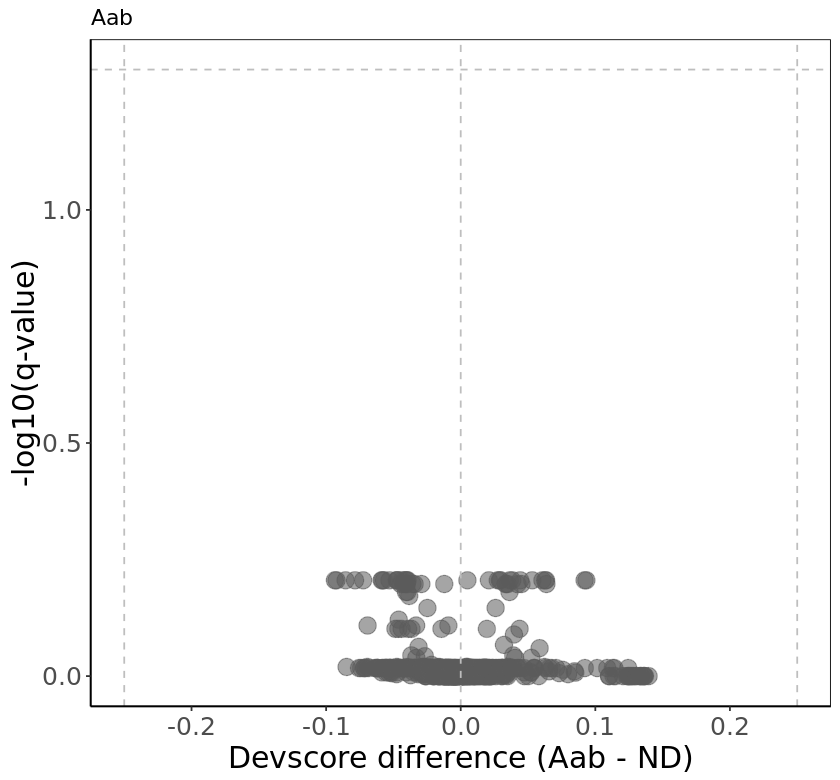

Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”


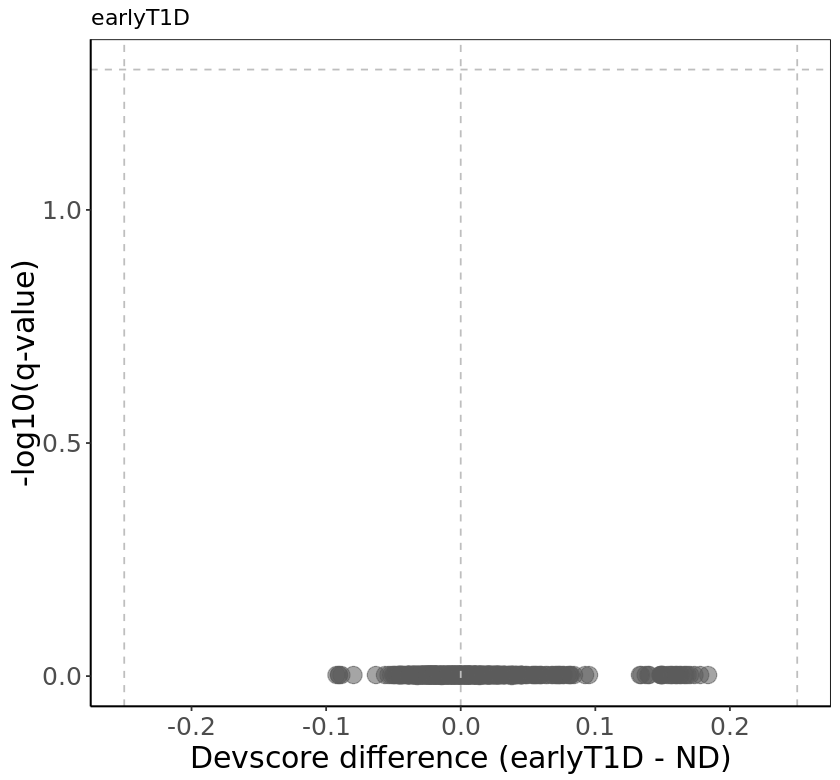

Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”


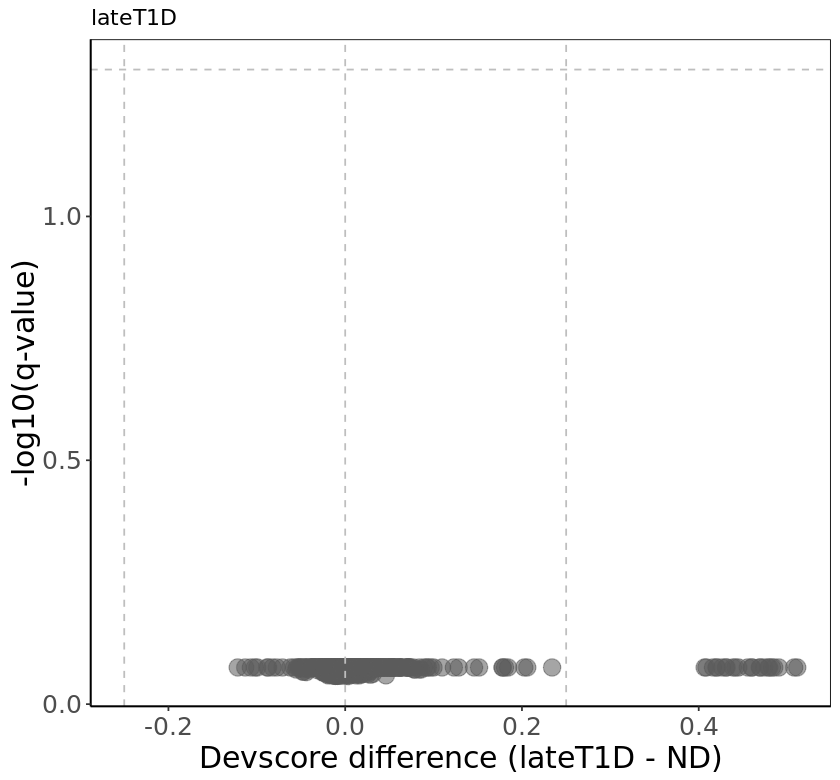

Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”


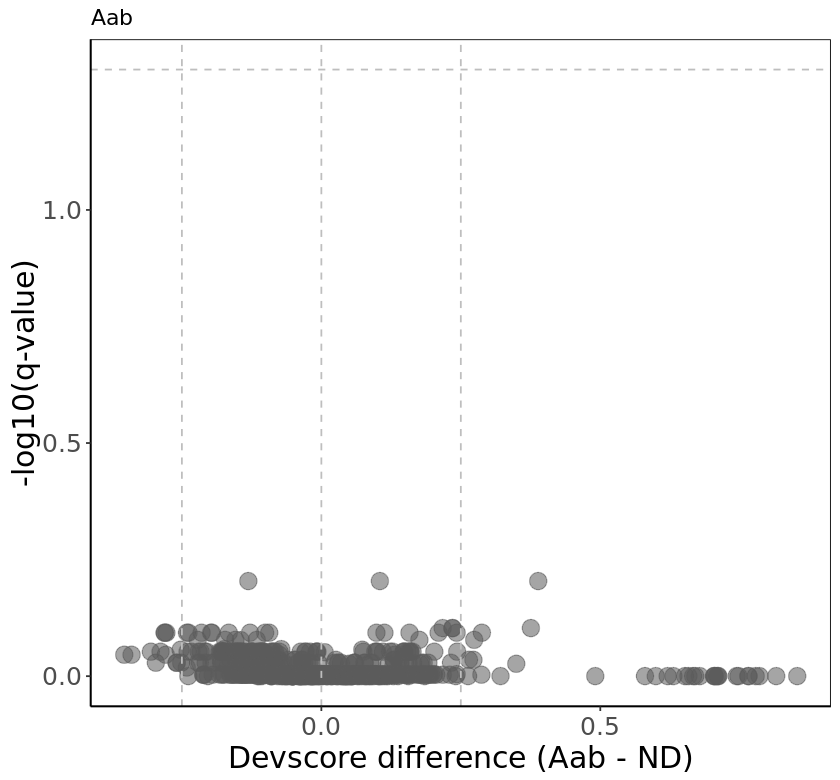

Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”


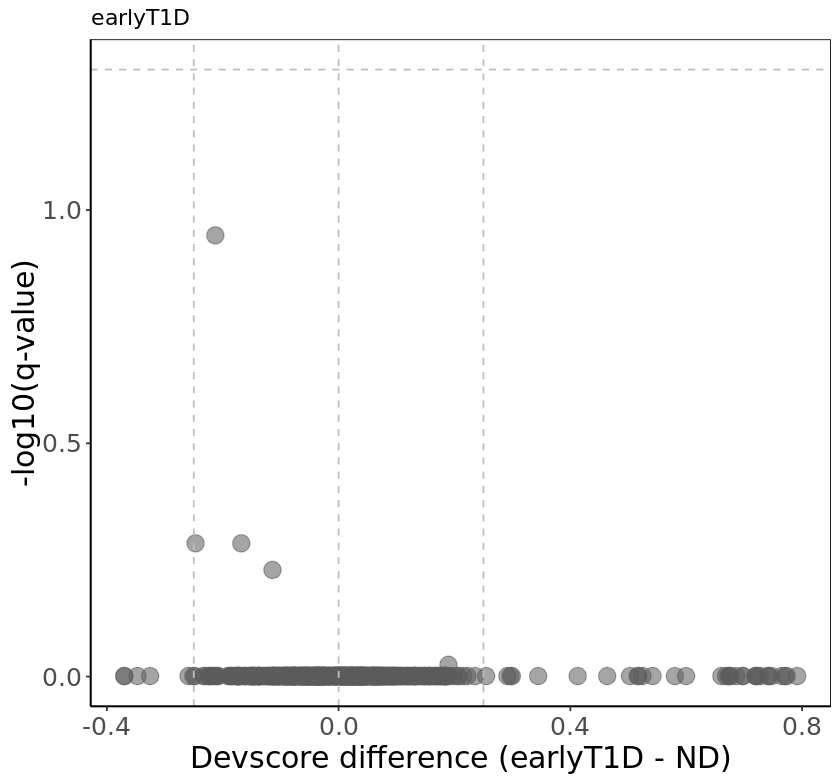

Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”


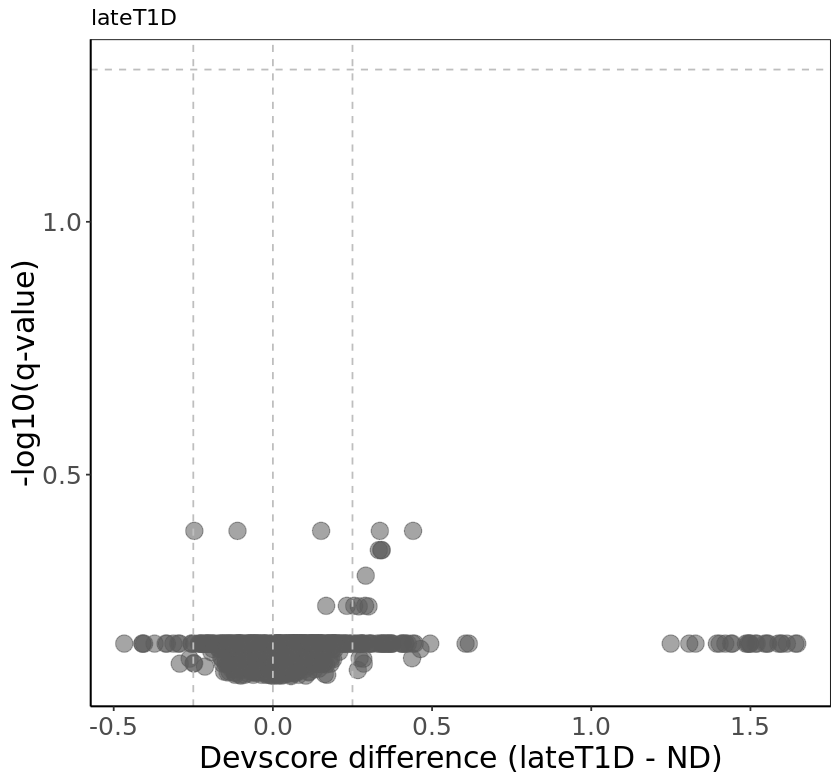

Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”


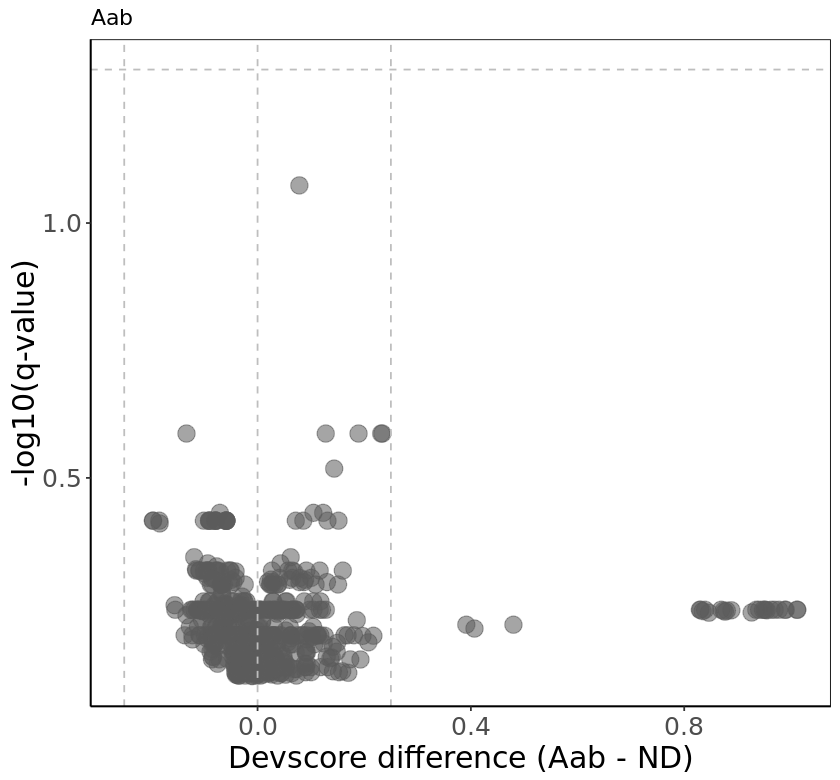

Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”


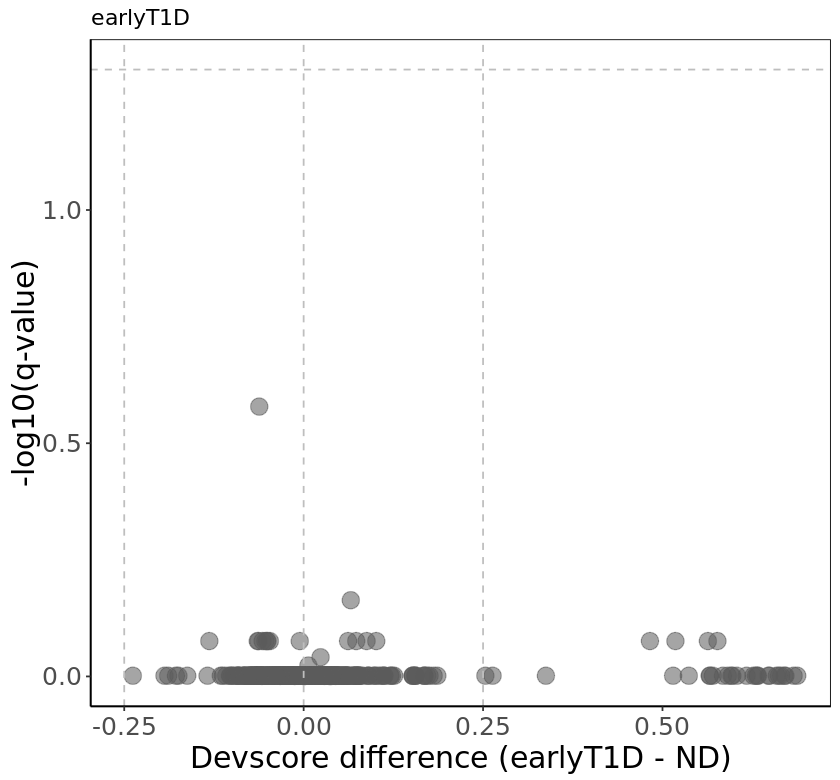

Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”


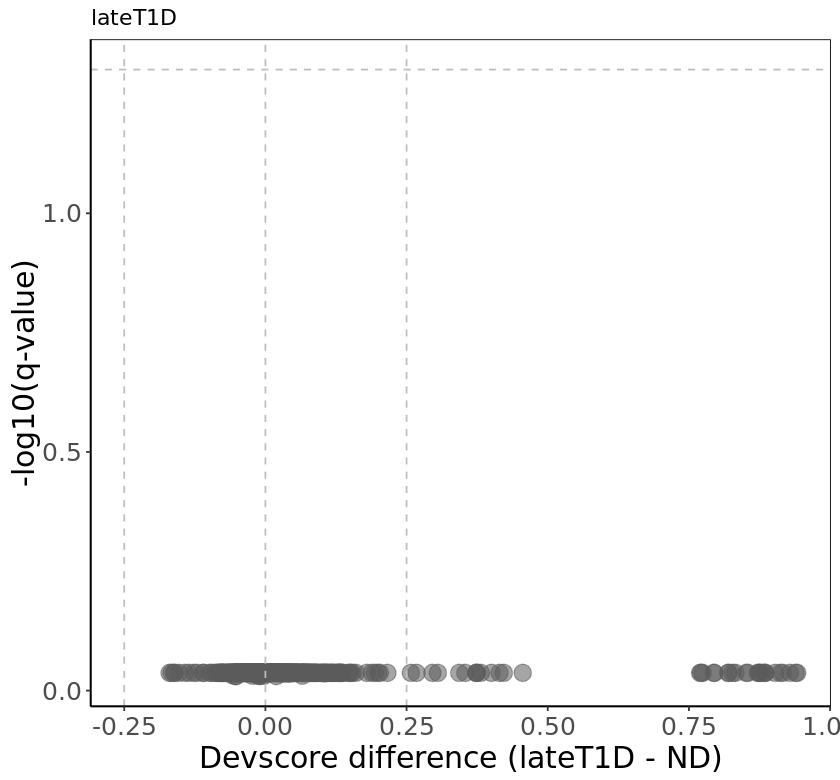

Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”


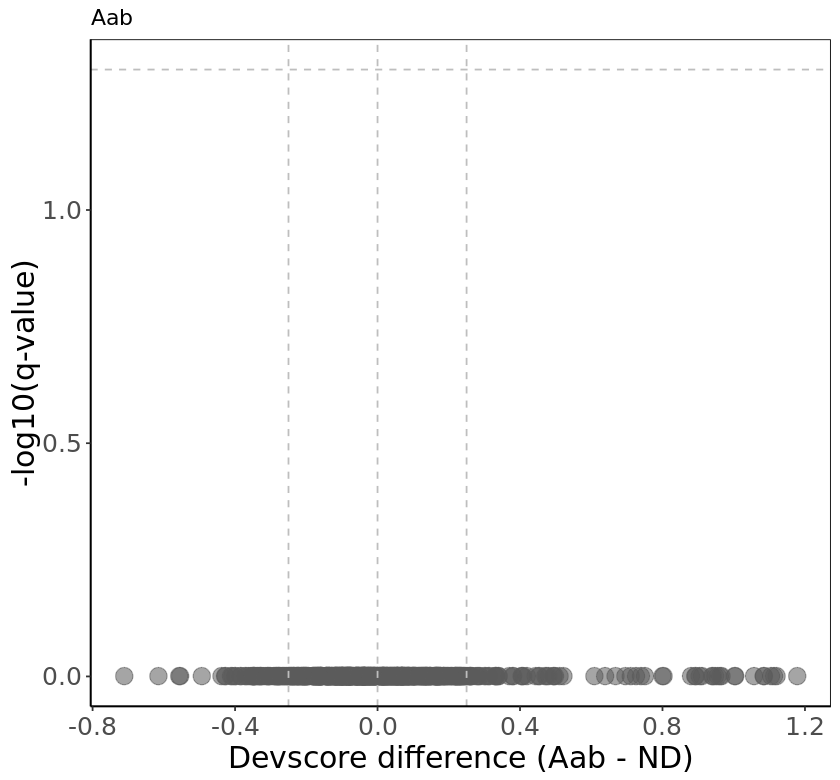

Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”


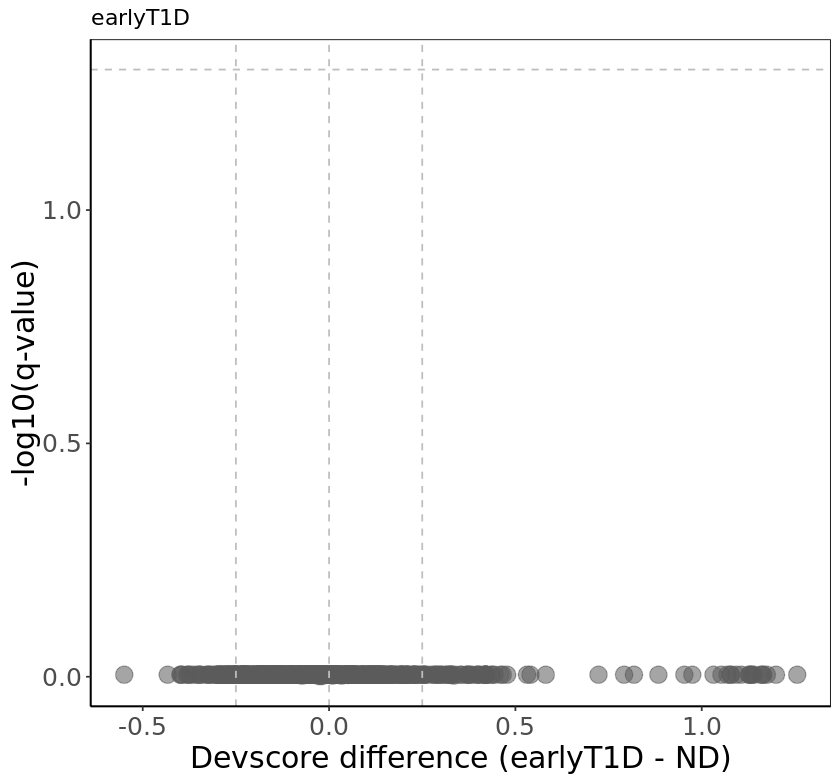

Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”


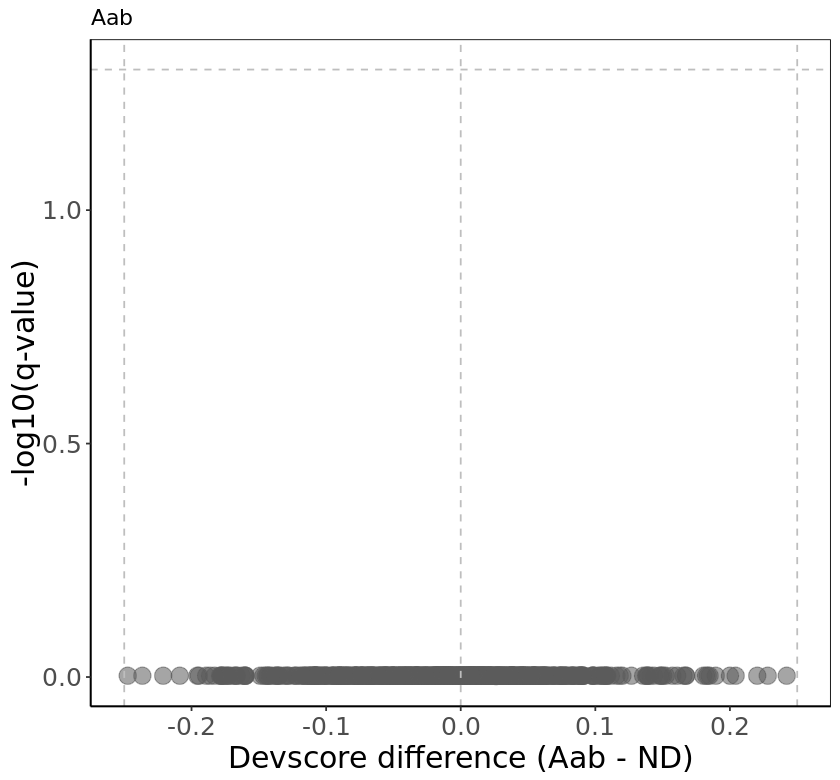

Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”


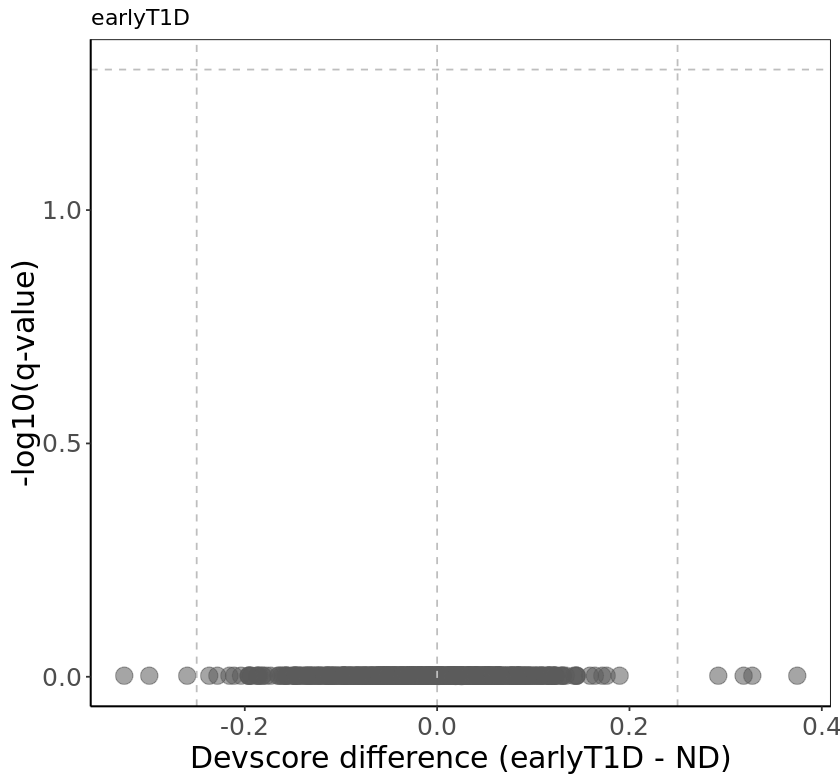

Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”


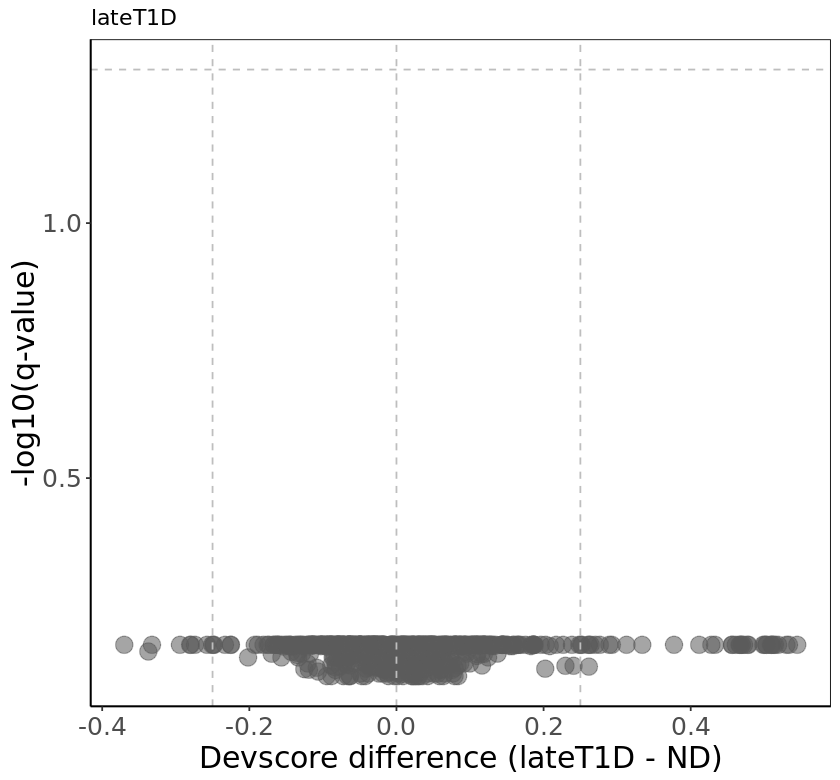

Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”


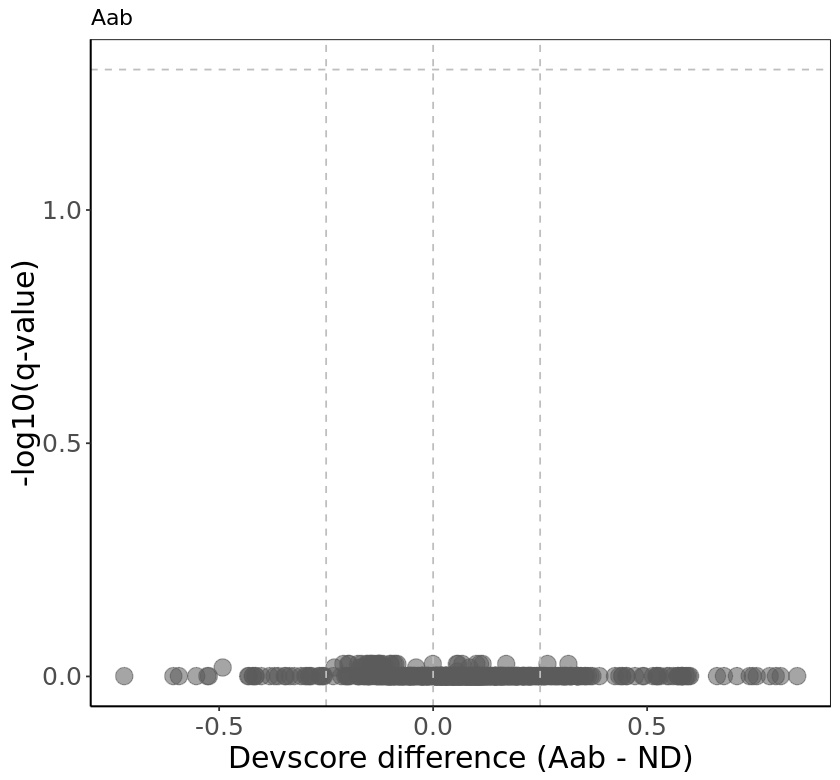

Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”


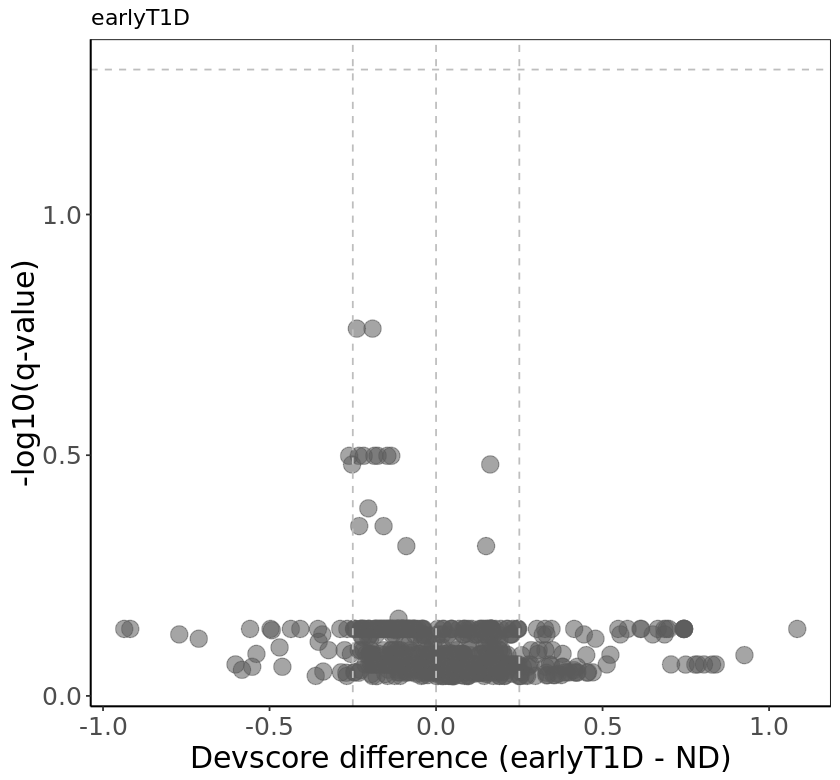

Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”


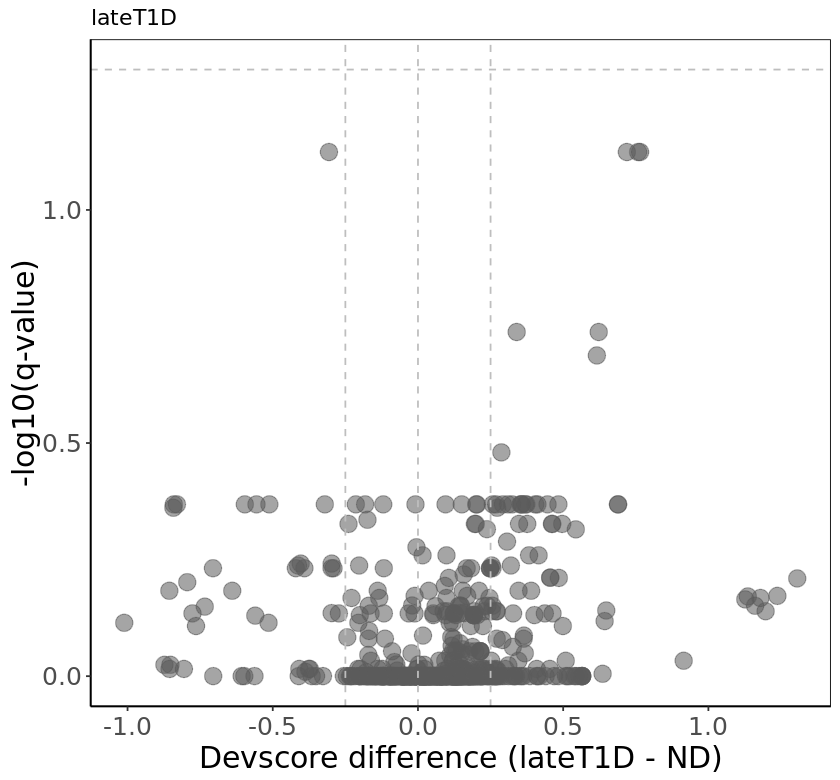

Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”


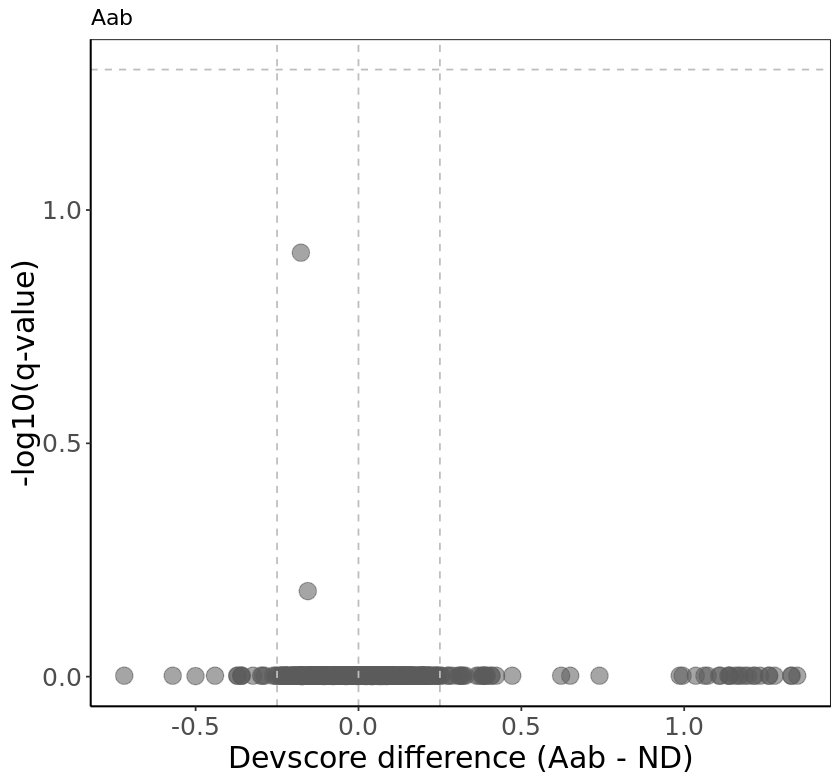

Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”


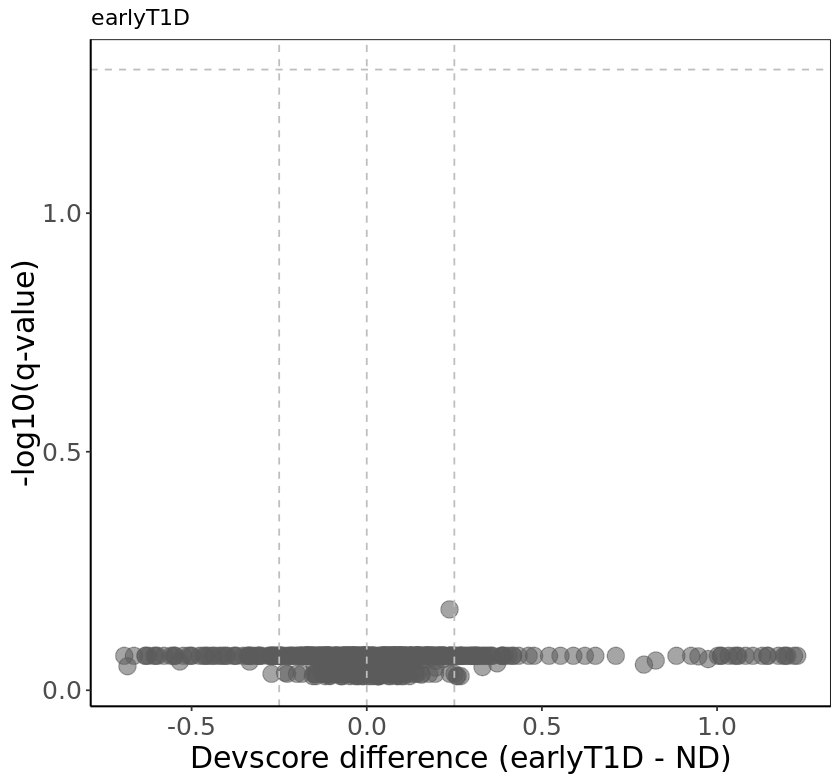

Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”


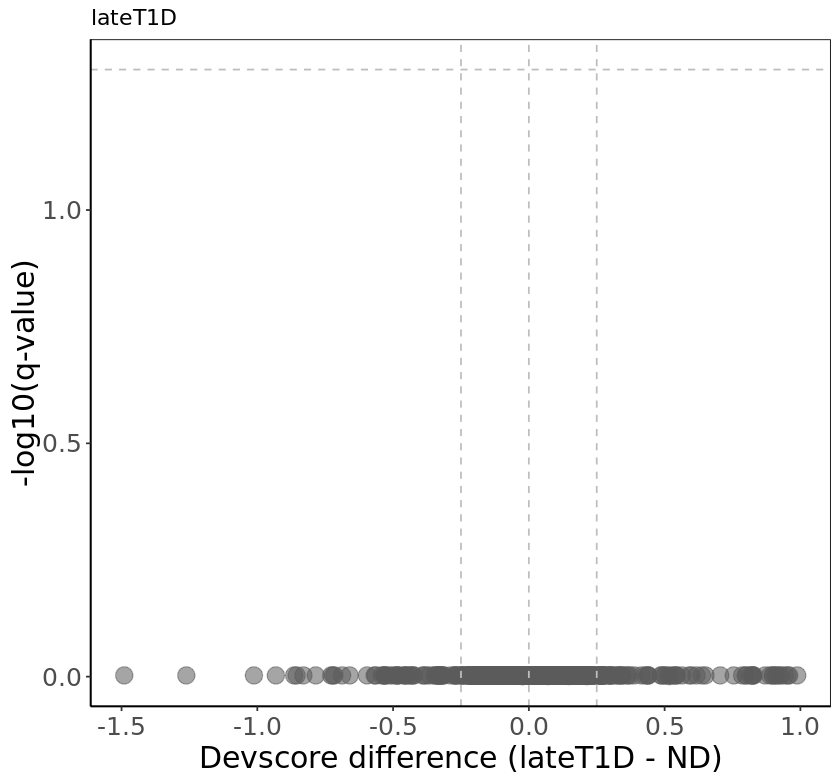

Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”


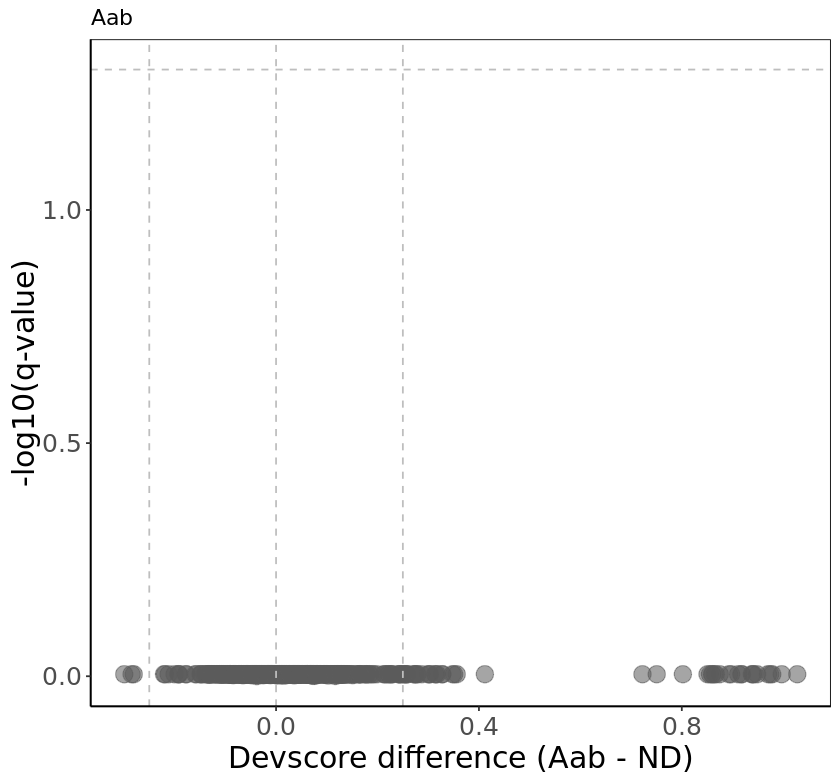

Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”


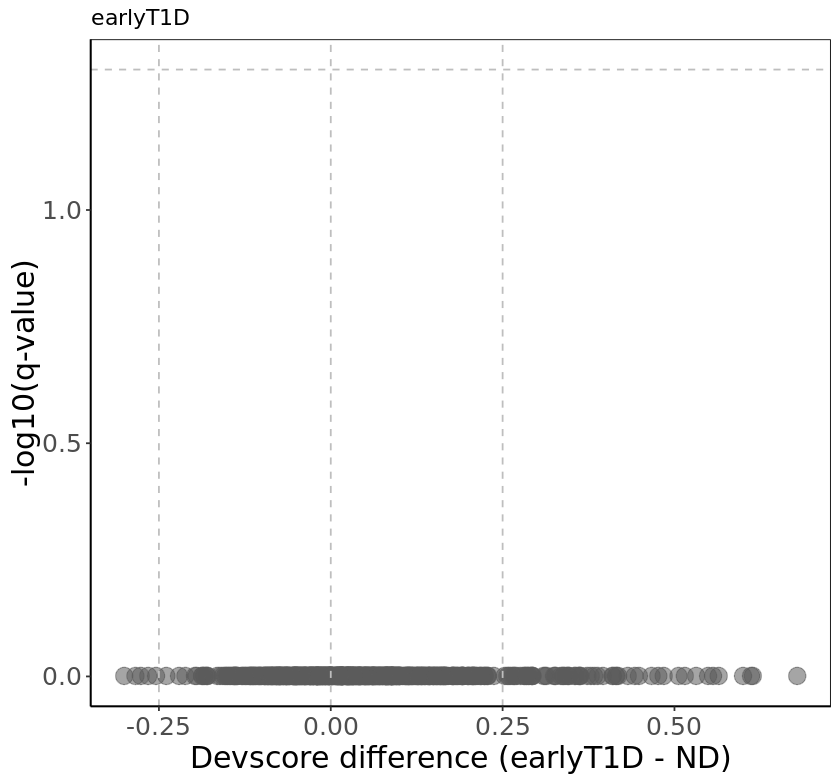

Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”


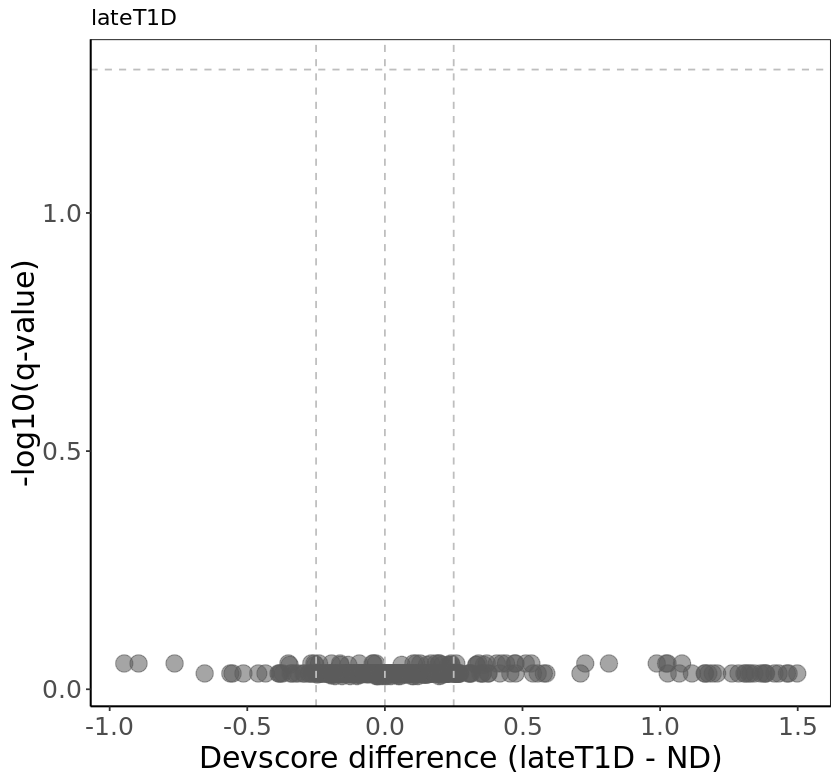

Warning message:
“Removed 690 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 690 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 690 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 690 rows containing missing values (`geom_text_repel()`).”


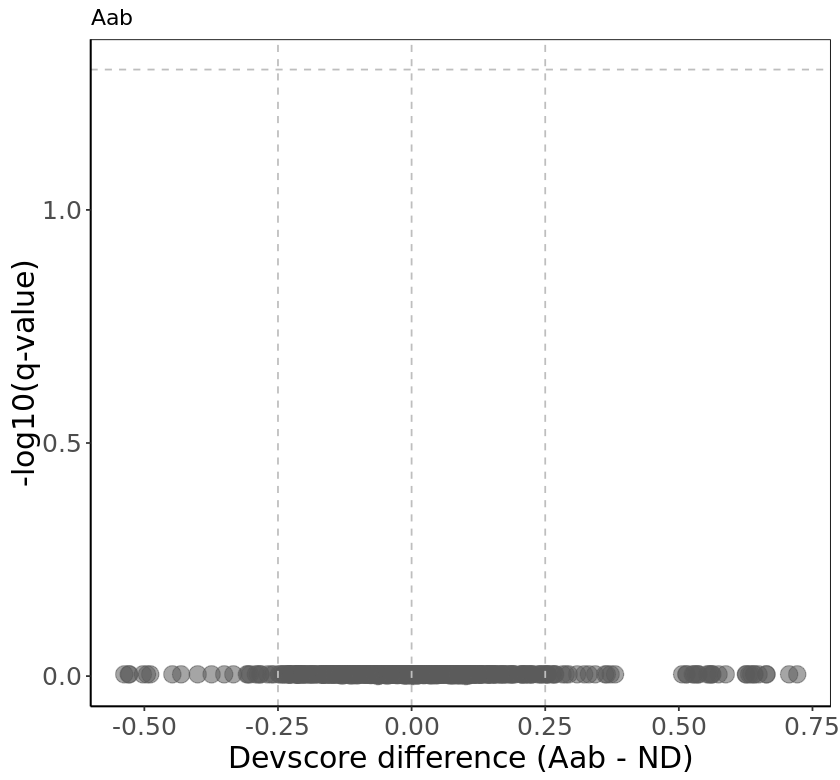

Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”


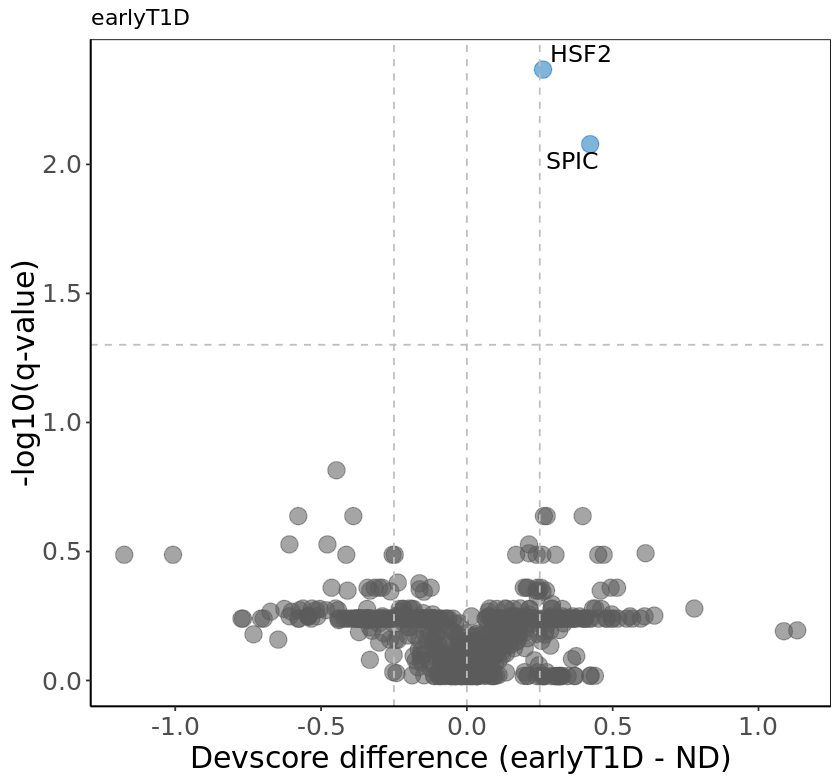

Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”


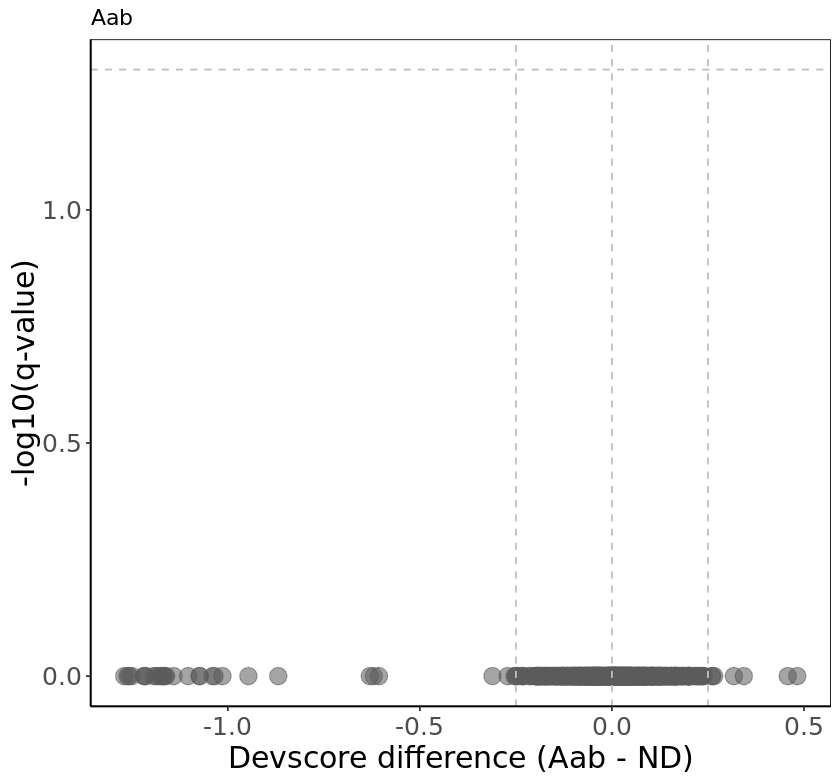

Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”


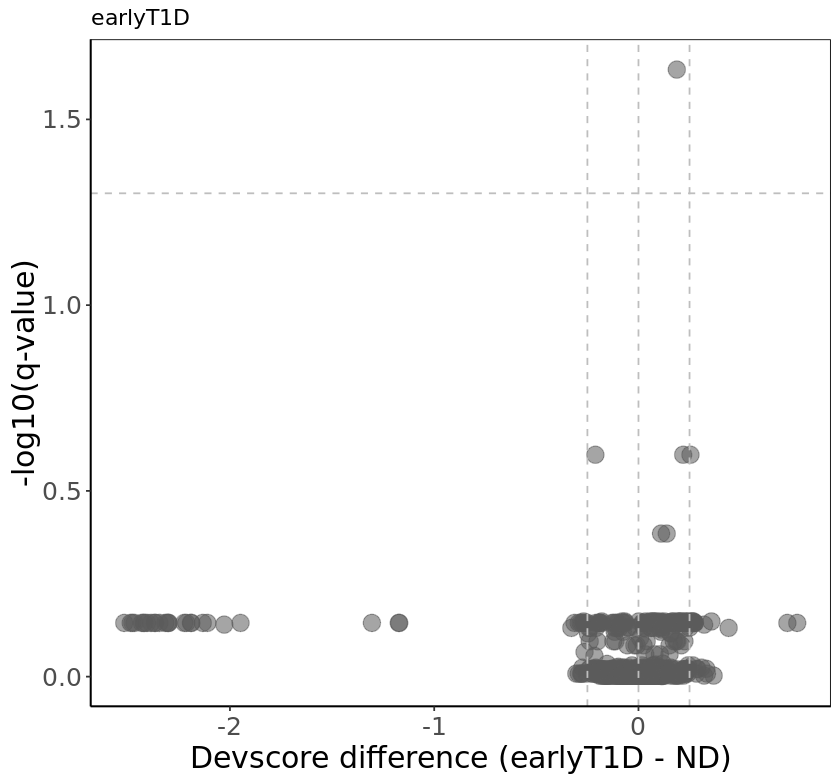

Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”


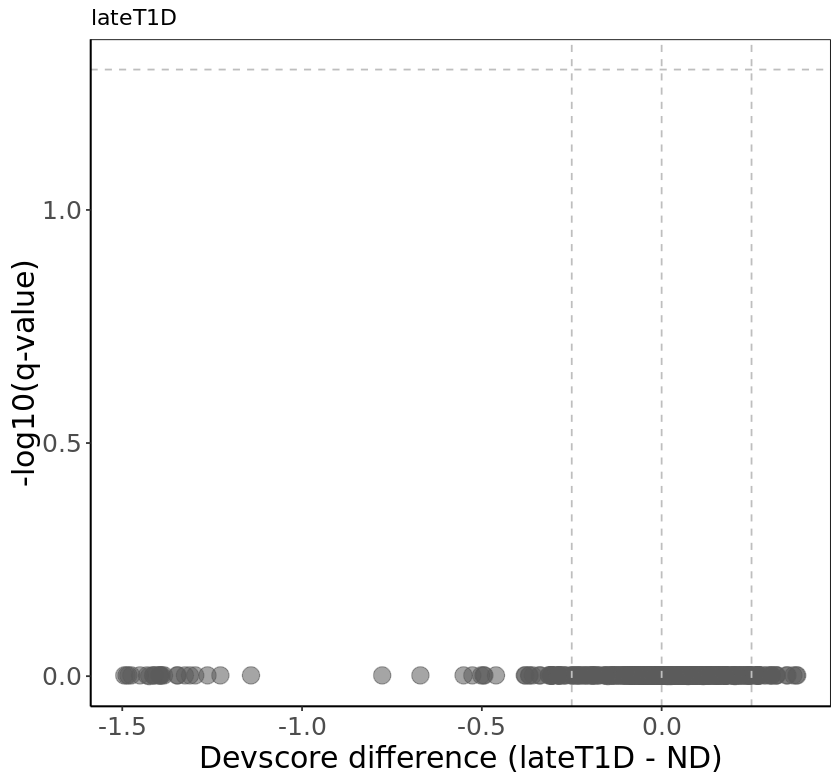

Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”


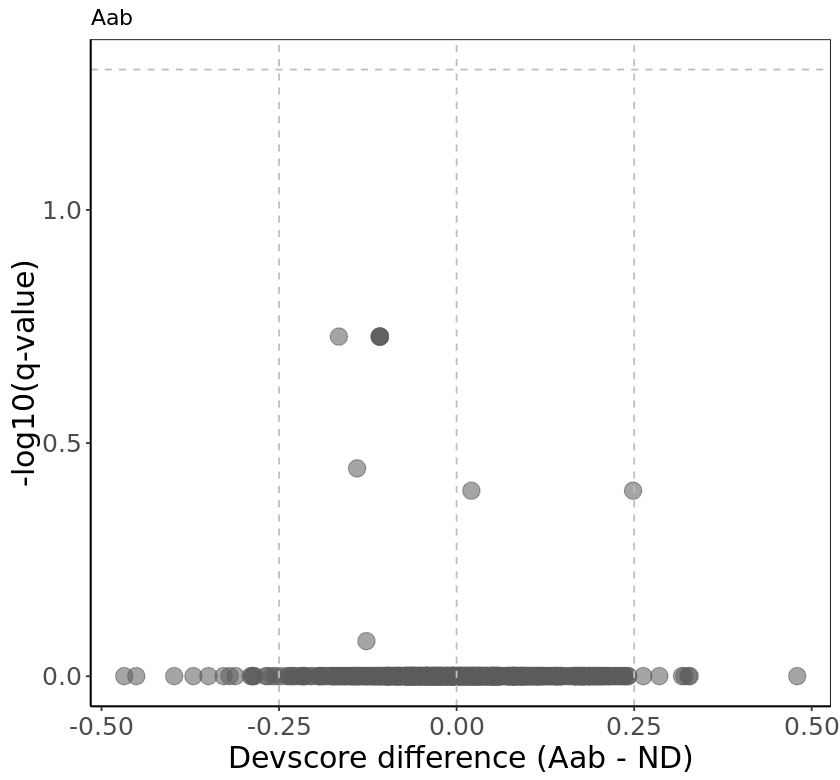

Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”


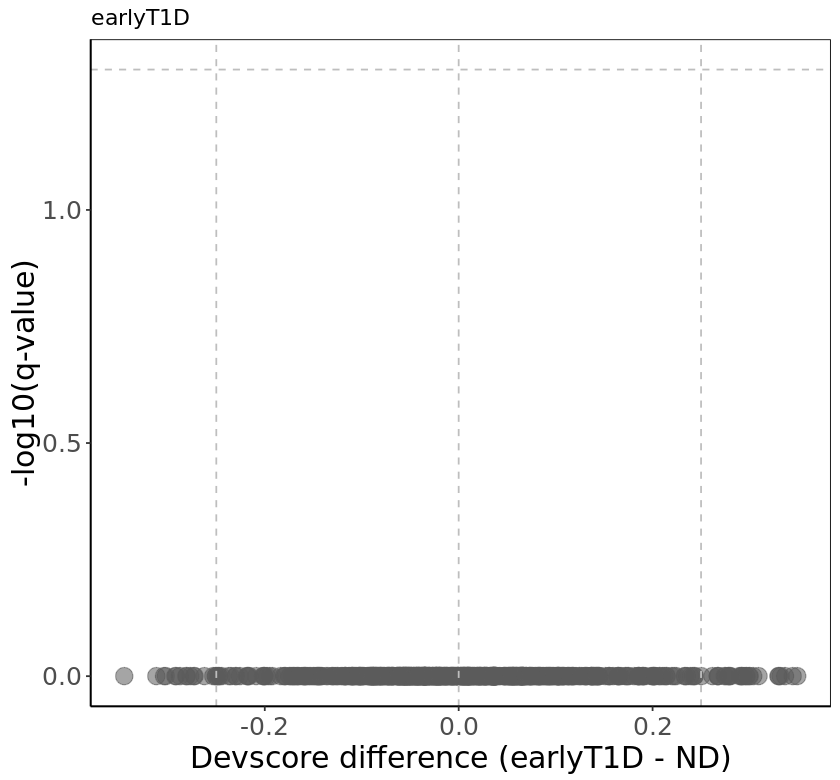

Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”


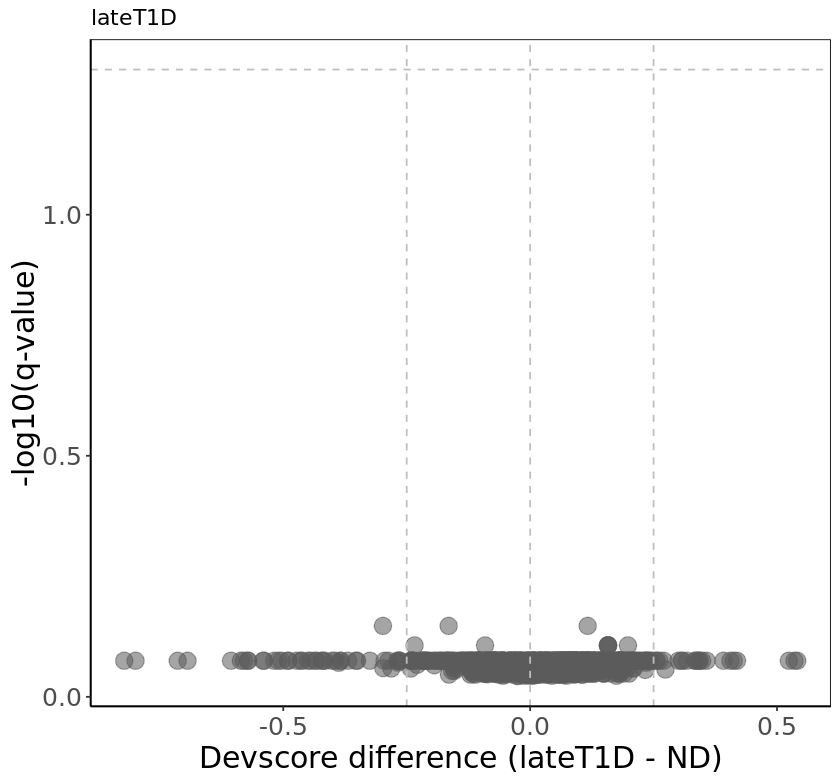

Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 692 rows containing missing values (`geom_text_repel()`).”


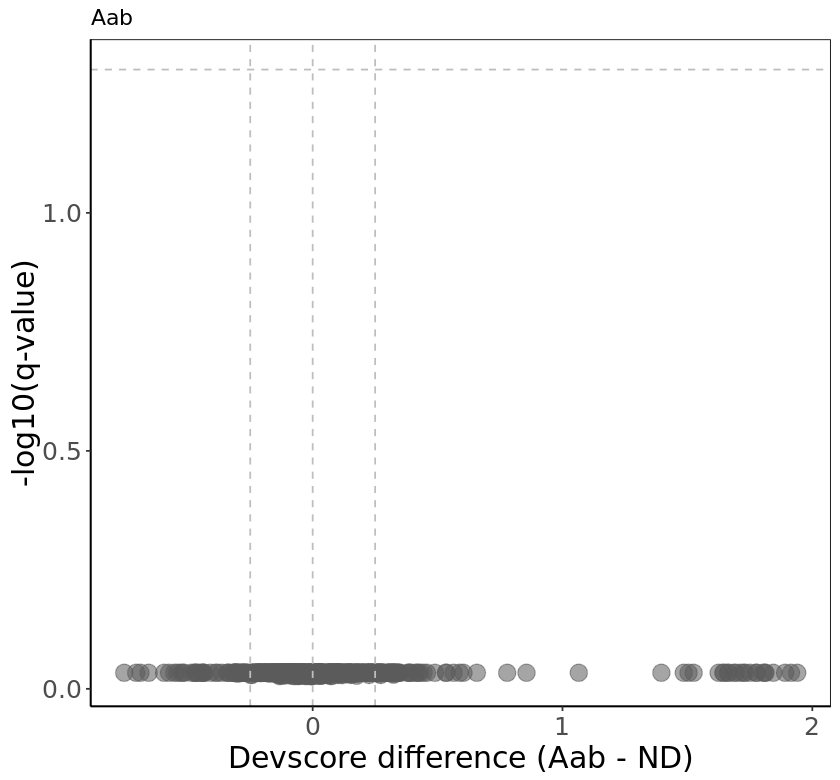

Warning message:
“Removed 691 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 691 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 691 rows containing missing values (`geom_text_repel()`).”
Warning message:
“Removed 691 rows containing missing values (`geom_text_repel()`).”


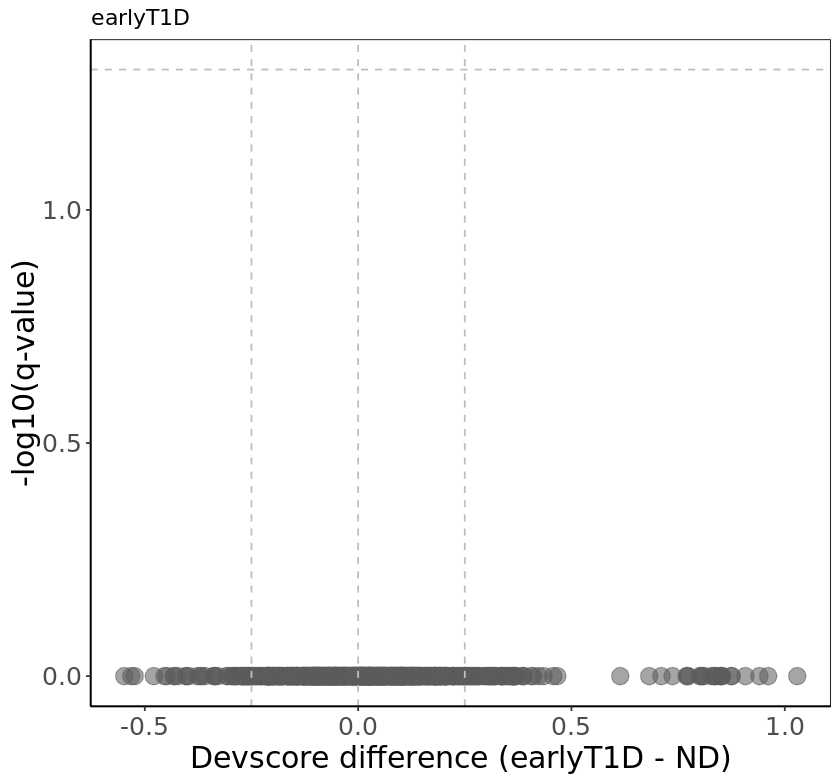

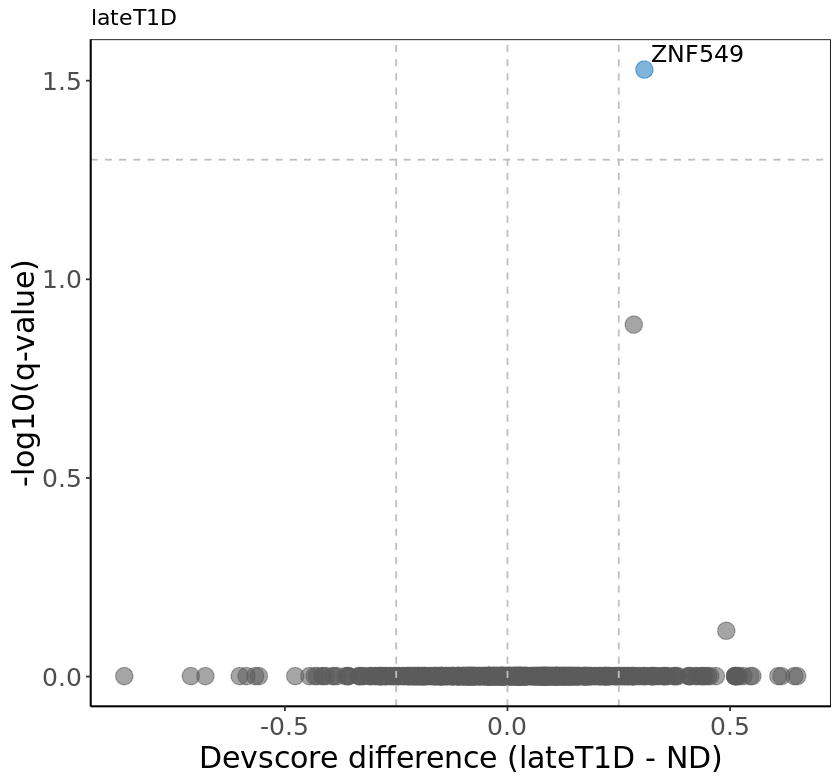

In [33]:
# Make and save volcano plots

# Select cutoffs for plot
delta_cutoff <- 0.25
q_cutoff <- 0.05

for (cell in names(volcano_data)) {
    # Select conditions to compare
    tested <- str_replace(colnames(volcano_data[[cell]][str_detect(colnames(volcano_data[[cell]]), 'q.value')]), '.q.value','')
    tested
    
    for (case in tested) {
        #Calculate difference in accessibility
        volcano_data[[cell]][[paste0("diff.", case)]] <- volcano_data[[cell]][[case]] - volcano_data[[cell]]$ND
        
        #Add colors
        volcano_data[[cell]][[paste0("color.", case)]] <- ifelse(abs(volcano_data[[cell]][[paste0("diff.", case)]]) <= delta_cutoff, 'grey', #doesn't pass delta cutoff
                             ifelse(volcano_data[[cell]][[paste0(case, '.q.value')]] >= q_cutoff, 'grey', #doesn't pass padj cutoff
                                    ifelse(volcano_data[[cell]][[paste0("diff.", case)]] < 0, 'red', #negative diff
                                           'blue'))) #positive diff 
        #Add labels for significant ones
        volcano_data[[cell]][[paste0("label.", case)]] <- NA
        to_label <- subset(volcano_data[[cell]], abs(volcano_data[[cell]][[paste0("diff.", case)]]) > delta_cutoff & 
                           volcano_data[[cell]][[paste0(case,'.q.value')]] < q_cutoff)
        volcano_data[[cell]][row.names(to_label),][[paste0("label.", case)]] <- str_split_fixed(row.names(to_label), '_', 2)[,2]
        
        # Make Volcano plot
        options(repr.plot.width=7, repr.plot.height=6.5)
        theme_set(theme_classic())
        p1 <- ggplot(data=volcano_data[[cell]], aes(x=.data[[paste0("diff.", case)]], y=-log10(.data[[paste0(case,'.q.value')]]), 
                                            col=.data[[paste0("color.", case)]], label=.data[[paste0("label.", case)]])) +
                geom_point(aes(alpha=0.7, size=1)) + 
                scale_color_manual(values=c('grey'='#5C5C5C', 'blue'='#1976BD', 'red'='#BD1919')) +
                geom_vline(xintercept=c(-delta_cutoff, 0, delta_cutoff), col="grey", linetype='dashed') + 
                geom_hline(yintercept=-log10(q_cutoff), col="grey", linetype='dashed') + 
                ggrepel::geom_text_repel(col=c("black"), size=5) +
                xlab(sprintf('Devscore difference (%s - %s)',case, 'ND')) + 
                ylab('-log10(q-value)') + ggtitle(case) + 
                theme(legend.position = "none", panel.border=element_rect(colour = 'black', fill=NA), 
                      axis.title.x=element_text(size=18, vjust=0.5), axis.text.x=element_text(size=15, vjust=0.5),
                      axis.title.y=element_text(size=18, vjust=0.5), axis.text.y=element_text(size=15, vjust=0.5)) 
        
        print(p1)
        
        #Save the results
        ggsave(plot=p1, filename=paste0("/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_",
                                       cell,"_lmer_volcano_ND_vs_",case,".pdf"), width=7, height=6.5)
        ggsave(plot=p1, filename=paste0("/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_",
                                       cell,"_lmer_volcano_ND_vs_",case,".png"), width=7, height=6.5)
        ggsave(plot=p1, filename=paste0("/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_",
                                       cell,"_lmer_volcano_ND_vs_",case,".svg"), width=7, height=6.5)
    }
    
    #Save the data so plotting is easier down the road
    write.table(volcano_data[[cell]], paste0("/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_",
                                       cell,"_lmer_volcano_data.tsv"),
               col.names=T, row.names=T, quote=F, sep='\t')
}

### Boxplots - Sample Pseudobulk

In [ ]:
for (cell in names(sample_data)) {
    # Load in data and order disease states
    boxplot_data <- sample_data[[cell]]
    boxplot_data$groups[boxplot_data$groups=='earlyT1D'] <- 'Early_T1D'
    boxplot_data$groups[boxplot_data$groups=='lateT1D'] <- 'Late_T1D'
    boxplot_data$groups <- factor(boxplot_data$groups, levels=c('ND','Aab','Early_T1D'))
    
    # Create output directory
    dir.create(paste0("/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_Boxplots/",
                      cell))
    
    #for (i in 3:4) {
    for (i in 3:ncol(boxplot_data)) {
        motif <- colnames(boxplot_data)[i]
        print(motif)
        
        # Make boxplot
        p1 <- ggplot(boxplot_data, aes(x=groups, y=.data[[motif]], fill=groups)) + geom_boxplot(outlier.shape=NA) + geom_jitter(width=.2) +
                xlab("Disease State") + 
                ylab('Motif Accessibility') + ggtitle(motif) +
                theme(legend.position = "none", panel.border=element_rect(colour = 'black', fill=NA), 
                      axis.title.x=element_text(size=18, vjust=0.5), axis.text.x=element_text(size=15, vjust=0.5),
                      axis.title.y=element_text(size=18, vjust=0.5), axis.text.y=element_text(size=15, vjust=0.5)) 
        #print(p1)
        
        #Save boxplots
        ggsave(plot=p1, filename=paste0("/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_Boxplots/",cell,
                                        "/240214_WE_",cell,"_",motif,"_sample_boxplot.pdf"), width=7, height=6.5)
        ggsave(plot=p1, filename=paste0("/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_Boxplots/",cell,
                                        "/240214_WE_",cell,"_",motif,"_sample_boxplot.png"), width=7, height=6.5)
        ggsave(plot=p1, filename=paste0("/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_Boxplots/",cell,
                                        "/240214_WE_",cell,"_",motif,"_sample_boxplot.svg"), width=7, height=6.5)
    }
    
    #Save data
    write.table(boxplot_data, paste0("/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_Boxplots/",cell,
                                        "_sample_boxplot_data.tsv"),
               col.names=T, row.names=T, quote=F, sep='\t')
}

[1] "lateT1D_weighted_barcode"
[1] "MA0030.1_FOXF2"
[1] "MA0031.1_FOXD1"
[1] "MA0051.1_IRF2"
[1] "MA0059.1_MAX::MYC"
[1] "MA0066.1_PPARG"
[1] "MA0069.1_PAX6"
[1] "MA0070.1_PBX1"
[1] "MA0071.1_RORA"
[1] "MA0072.1_RORA"
[1] "MA0073.1_RREB1"
[1] "MA0074.1_RXRA::VDR"
[1] "MA0077.1_SOX9"
[1] "MA0084.1_SRY"
[1] "MA0091.1_TAL1::TCF3"
[1] "MA0101.1_REL"
[1] "MA0107.1_RELA"
[1] "MA0115.1_NR1H2::RXRA"
[1] "MA0119.1_NFIC::TLX1"
[1] "MA0130.1_ZNF354C"
[1] "MA0139.1_CTCF"
[1] "MA0149.1_EWSR1-FLI1"
[1] "MA0138.2_REST"
[1] "MA0155.1_INSM1"
[1] "MA0159.1_RARA::RXRA"
[1] "MA0163.1_PLAG1"
[1] "MA0259.1_ARNT::HIF1A"
[1] "MA0468.1_DUX4"
[1] "MA0476.1_FOS"
[1] "MA0478.1_FOSL2"
[1] "MA0479.1_FOXH1"
[1] "MA0488.1_JUN"
[1] "MA0492.1_JUND"
[1] "MA0497.1_MEF2C"
[1] "MA0501.1_MAF::NFE2"
[1] "MA0504.1_NR2C2"
[1] "MA0517.1_STAT1::STAT2"
[1] "MA0523.1_TCF7L2"
[1] "MA0527.1_ZBTB33"
[1] "MA0076.2_ELK4"
[1] "MA0258.2_ESR2"
[1] "MA0137.3_STAT1"
[1] "MA0144.2_STAT3"
[1] "MA0140.2_GATA1::TAL1"
[1] "MA0593.1_FOXP2"
[1] "M

### Boxplots - Barcode By Sample

In [ ]:
for (cell in names(new_df)) {
    #Order disease states
    barcode_boxplot_data <- new_df[[cell]]
    barcode_boxplot_data$groups[barcode_boxplot_data$groups=='earlyT1D'] <- 'Early_T1D'
    barcode_boxplot_data$groups[barcode_boxplot_data$groups=='lateT1D'] <- 'Late_T1D'
    barcode_boxplot_data$groups <- factor(barcode_boxplot_data$groups, levels=c('ND','Aab','Early_T1D'))
    
    #Create output directory
    dir.create(paste0("/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_Boxplots/",
                      cell))
    
    #Create color schema
    samples_color <- select(barcode_boxplot_data, groups, samples) %>%
        arrange(groups, samples) 
    
    samples_color <- samples_color[!duplicated(samples_color),]
    
    reds <- brewer.pal(n = (sum(samples_color$groups == 'ND') + 1), name = 'Reds')
    greens <- brewer.pal(n = (sum(samples_color$groups == 'Aab') + 1), name = 'Greens')
    blues <- brewer.pal(n = (sum(samples_color$groups == 'Early_T1D') + 1), name = 'Blues')
    purples <- brewer.pal(n = (sum(samples_color$groups == 'Late_T1D') + 1), name = 'Purples')
    
    custom_pallette <- c(reds[2:length(reds)], greens[2:length(greens)], blues[2:length(blues)], purples[2:length(purples)])
    
    names(custom_pallette) <- samples_color$samples
    
    
    for (i in (ncol(barcode_boxplot_data) - 691):(ncol(barcode_boxplot_data) - 690)) {
    #for (i in (ncol(barcode_boxplot_data) - 691):ncol(barcode_boxplot_data)) {
        motif <- colnames(barcode_boxplot_data)[i]
        print(motif)
        
        #Make boxplot
        p1 <- ggplot(barcode_boxplot_data, aes(x=groups, y=.data[[motif]], fill=samples)) + geom_boxplot() +
                xlab("Disease State") + 
                ylab('Motif Accessibility') + ggtitle(motif) +
                scale_fill_manual(values=custom_pallette) +
                theme(panel.border=element_rect(colour = 'black', fill=NA), 
                      axis.title.x=element_text(size=18, vjust=0.5), axis.text.x=element_text(size=15, vjust=0.5),
                      axis.title.y=element_text(size=18, vjust=0.5), axis.text.y=element_text(size=15, vjust=0.5)) 
        #print(p1)
        
        #Save the boxplot
        ggsave(plot=p1, filename=paste0("/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_Boxplots/",cell,
                                        "/240214_WE_",cell,"_",motif,"_barcode_boxplot.pdf"), width=7, height=6.5)
        ggsave(plot=p1, filename=paste0("/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_Boxplots/",cell,
                                        "/240214_WE_",cell,"_",motif,"_barcode_boxplot.png"), width=7, height=6.5)
        ggsave(plot=p1, filename=paste0("/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_Boxplots/",cell,
                                        "/240214_WE_",cell,"_",motif,"_barcode_boxplot.svg"), width=7, height=6.5)
    }
    
    #Save data
    write.table(barcode_boxplot_data, paste0("/nfs/lab/welison/multiome/chromvar/240209_ChromVar_Outputs/240214_DM_Plots/240214_WE_Boxplots/",cell,
                                        "_barcode_boxplot_data.tsv"),
               col.names=T, row.names=T, quote=F, sep='\t')
}